In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import pandas as pd
from check_stationarity import load_data, load_train_data

C:\Users\giada\AppData\Local\Temp\ipykernel_9324\3099670554.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gdp_series['sasdate'] = pd.to_datetime(gdp_series['sasdate'], errors='coerce')


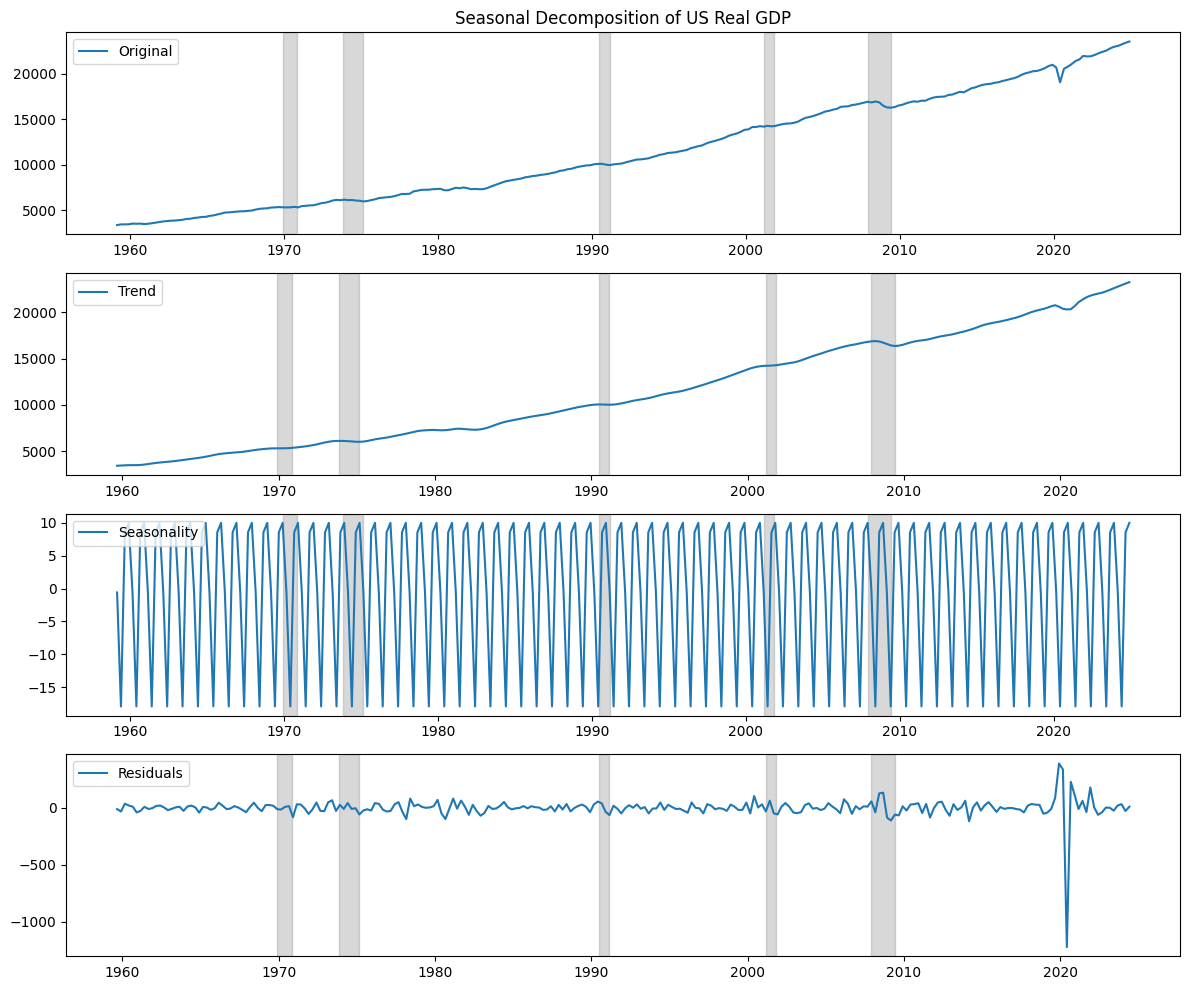

In [7]:

# Ensure GDP series is datetime-indexed
# Convert date column to datetime

qd_df = pd.read_csv("FRED_QD.csv")
gdp_series = qd_df[['sasdate', 'GDPC1']].copy()
gdp_series['sasdate'] = pd.to_datetime(gdp_series['sasdate'], errors='coerce')
gdp_series.dropna(subset=['sasdate'], inplace=True)
gdp_series.set_index('sasdate', inplace=True)

# Perform seasonal decomposition (assume quarterly frequency: freq=4)
decomposition = seasonal_decompose(gdp_series['GDPC1'], model='additive', period=4)

# Plot the components: Original, Trend, Seasonal, Residual
plt.figure(figsize=(12, 10))

# Define recession periods from NBER dates
recessions = [
    ('1960-04-01', '1961-02-01'),
    ('1969-12-01', '1970-11-01'),
    ('1973-11-01', '1975-03-01'),
    ('1980-01-01', '1980-07-01'),
    ('1981-07-01', '1982-11-01'),
    ('1990-07-01', '1991-03-01'),
    ('2001-03-01', '2001-11-01'),
    ('2007-12-01', '2009-06-01'),
    ('2020-02-01', '2020-04-01')
]

# Convert recession dates to datetime
recessions = [(pd.to_datetime(start), pd.to_datetime(end)) for start, end in recessions]

# Plot 1: Original
ax1 = plt.subplot(411)
plt.plot(gdp_series['GDPC1'], label='Original')
plt.legend(loc='upper left')
plt.title('Seasonal Decomposition of US Real GDP')

# Shade recession periods in each subplot
for start, end in recessions:
    if start in gdp_series.index or end in gdp_series.index:
        ax1.axvspan(start, end, color='gray', alpha=0.3)

# Plot 2: Trend
ax2 = plt.subplot(412)
plt.plot(decomposition.trend, label='Trend')
plt.legend(loc='upper left')

# Shade recession periods
for start, end in recessions:
    if start in gdp_series.index or end in gdp_series.index:
        ax2.axvspan(start, end, color='gray', alpha=0.3)

# Plot 3: Seasonal
ax3 = plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonality')
plt.legend(loc='upper left')

# Shade recession periods
for start, end in recessions:
    if start in gdp_series.index or end in gdp_series.index:
        ax3.axvspan(start, end, color='gray', alpha=0.3)

# Plot 4: Residuals
ax4 = plt.subplot(414)
plt.plot(decomposition.resid, label='Residuals')
plt.legend(loc='upper left')

# Shade recession periods
for start, end in recessions:
    if start in gdp_series.index or end in gdp_series.index:
        ax4.axvspan(start, end, color='gray', alpha=0.3)

plt.tight_layout()
plt.show()


Figure of quarterly GDP change 

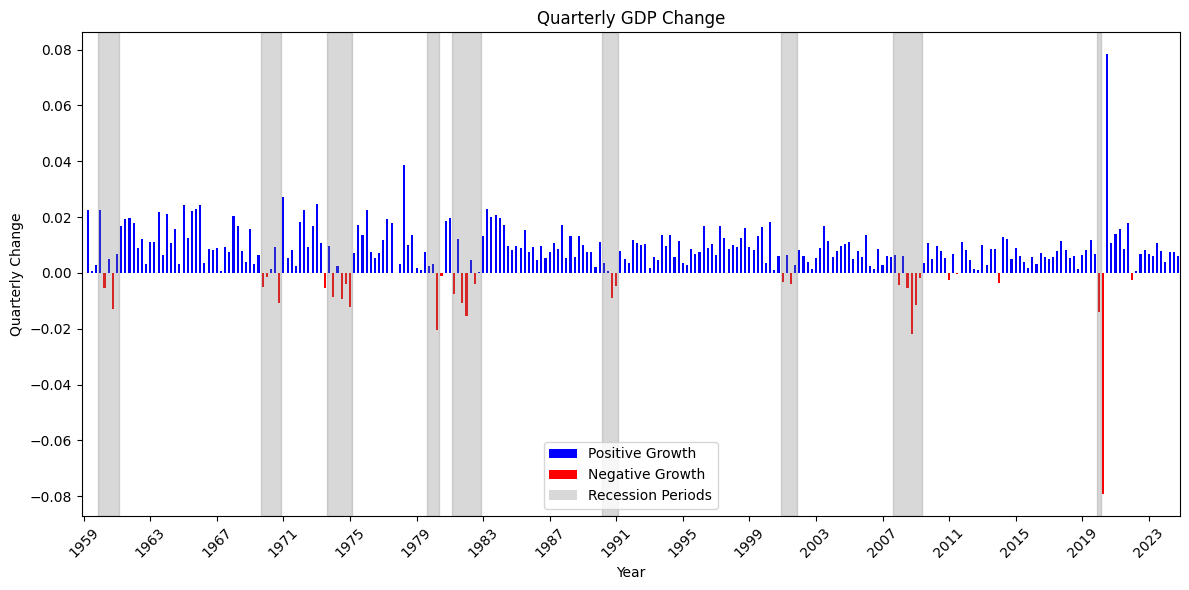

In [8]:
# Calculate quarterly GDP percentage change
gdp_series['GDP_Change'] = gdp_series['GDPC1'].pct_change()

# Plot the quarterly GDP change
plt.figure(figsize=(12, 6))
gdp_series['GDP_Change'].plot(kind='bar', color=gdp_series['GDP_Change'].apply(lambda x: 'red' if x < 0 else 'blue'))

# Define recession periods if they haven't been defined already
if 'recessions' not in locals():
    recessions = [
        ('1960-04-01', '1961-02-01'),
        ('1969-12-01', '1970-11-01'),
        ('1973-11-01', '1975-03-01'),
        ('1980-01-01', '1980-07-01'),
        ('1981-07-01', '1982-11-01'),
        ('1990-07-01', '1991-03-01'),
        ('2001-03-01', '2001-11-01'),
        ('2007-12-01', '2009-06-01'),
        ('2020-02-01', '2020-04-01')
    ]
    # Convert recession dates to datetime
    recessions = [(pd.to_datetime(start), pd.to_datetime(end)) for start, end in recessions]

# Shade recession periods
ax = plt.gca()
for start, end in recessions:
    try:
        # Find positions in the index
        start_idx = gdp_series.index.get_indexer([start], method='nearest')[0]
        end_idx = gdp_series.index.get_indexer([end], method='nearest')[0]
        
        # Add shaded area
        ax.axvspan(start_idx-0.5, end_idx+0.5, color='gray', alpha=0.3)
    except:
        print(f"Could not shade recession period {start} to {end}")

# Customize the plot
plt.title('Quarterly GDP Change')
plt.xlabel('Year')
plt.ylabel('Quarterly Change')
plt.xticks(ticks=range(0, len(gdp_series), 16), labels=gdp_series.index[::16].year, rotation=45)

# Add legend for recession periods
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='blue', label='Positive Growth'),
    Patch(facecolor='red', label='Negative Growth'),
    Patch(facecolor='gray', alpha=0.3, label='Recession Periods')
]
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

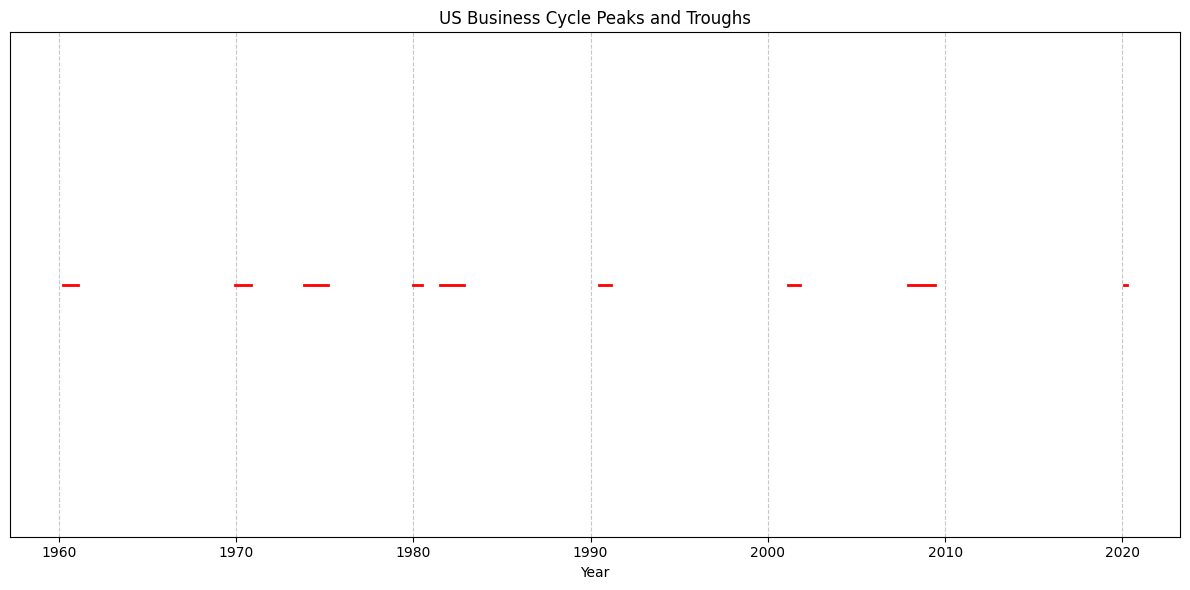

In [9]:
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Business cycle data
business_cycles = [
    {"peak": "", "trough": "1854-12-01"},
    {"peak": "1857-06-01", "trough": "1858-12-01"},
    {"peak": "1860-10-01", "trough": "1861-06-01"},
    {"peak": "1865-04-01", "trough": "1867-12-01"},
    {"peak": "1869-06-01", "trough": "1870-12-01"},
    {"peak": "1873-10-01", "trough": "1879-03-01"},
    {"peak": "1882-03-01", "trough": "1885-05-01"},
    {"peak": "1887-03-01", "trough": "1888-04-01"},
    {"peak": "1890-07-01", "trough": "1891-05-01"},
    {"peak": "1893-01-01", "trough": "1894-06-01"},
    {"peak": "1895-12-01", "trough": "1897-06-01"},
    {"peak": "1899-06-01", "trough": "1900-12-01"},
    {"peak": "1902-09-01", "trough": "1904-08-01"},
    {"peak": "1907-05-01", "trough": "1908-06-01"},
    {"peak": "1910-01-01", "trough": "1912-01-01"},
    {"peak": "1913-01-01", "trough": "1914-12-01"},
    {"peak": "1918-08-01", "trough": "1919-03-01"},
    {"peak": "1920-01-01", "trough": "1921-07-01"},
    {"peak": "1923-05-01", "trough": "1924-07-01"},
    {"peak": "1926-10-01", "trough": "1927-11-01"},
    {"peak": "1929-08-01", "trough": "1933-03-01"},
    {"peak": "1937-05-01", "trough": "1938-06-01"},
    {"peak": "1945-02-01", "trough": "1945-10-01"},
    {"peak": "1948-11-01", "trough": "1949-10-01"},
    {"peak": "1953-07-01", "trough": "1954-05-01"},
    {"peak": "1957-08-01", "trough": "1958-04-01"},
    {"peak": "1960-04-01", "trough": "1961-02-01"},
    {"peak": "1969-12-01", "trough": "1970-11-01"},
    {"peak": "1973-11-01", "trough": "1975-03-01"},
    {"peak": "1980-01-01", "trough": "1980-07-01"},
    {"peak": "1981-07-01", "trough": "1982-11-01"},
    {"peak": "1990-07-01", "trough": "1991-03-01"},
    {"peak": "2001-03-01", "trough": "2001-11-01"},
    {"peak": "2007-12-01", "trough": "2009-06-01"},
    {"peak": "2020-02-01", "trough": "2020-04-01"}
]

# Convert dates to datetime objects and filter out cycles before 1959
business_cycles = [
    {"peak": datetime.strptime(cycle["peak"], "%Y-%m-%d") if cycle["peak"] else None,
     "trough": datetime.strptime(cycle["trough"], "%Y-%m-%d") if cycle["trough"] else None}
    for cycle in business_cycles
    if (not cycle["trough"] or datetime.strptime(cycle["trough"], "%Y-%m-%d") >= datetime(1959, 1, 1))
]

# Create the plot
plt.figure(figsize=(12, 6))
for cycle in business_cycles:
    if cycle["peak"] and cycle["trough"]:
        plt.plot([cycle["peak"], cycle["trough"]], [1, 1], color='red', linewidth=2)
    elif cycle["trough"]:
        plt.scatter(cycle["trough"], 1, color='blue', label='Trough')

# Customize the plot
plt.title("US Business Cycle Peaks and Troughs")
plt.xlabel("Year")
plt.yticks([])
plt.gca().xaxis.set_major_locator(mdates.YearLocator(10))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

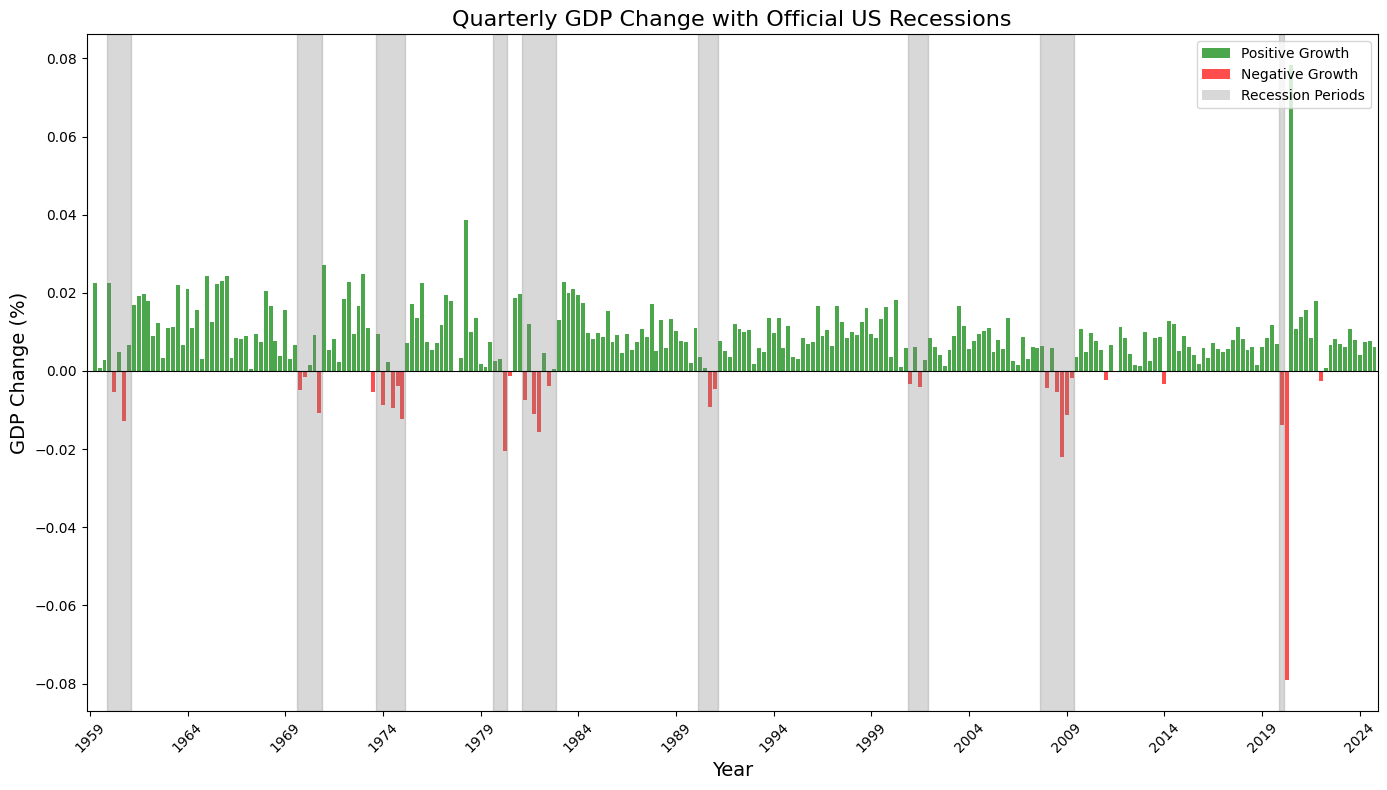

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Ensure we have the properly formatted GDP data
if 'GDP_Change' not in gdp_series.columns:
    gdp_series['GDP_Change'] = gdp_series['GDPC1'].pct_change()

# Define recession periods from NBER dates
recessions = [
    ('1960-04-01', '1961-02-01'),
    ('1969-12-01', '1970-11-01'),
    ('1973-11-01', '1975-03-01'),
    ('1980-01-01', '1980-07-01'),
    ('1981-07-01', '1982-11-01'),
    ('1990-07-01', '1991-03-01'),
    ('2001-03-01', '2001-11-01'),
    ('2007-12-01', '2009-06-01'),
    ('2020-02-01', '2020-04-01')
]

# Convert recession dates to datetime
recessions = [(pd.to_datetime(start), pd.to_datetime(end)) for start, end in recessions]

# Create the plot
fig, ax = plt.subplots(figsize=(14, 8))

# Plot GDP change
gdp_series['GDP_Change'].plot(kind='bar', ax=ax, color=gdp_series['GDP_Change'].apply(
    lambda x: 'red' if x < 0 else 'green'), width=0.8, alpha=0.7)

# Shade recession periods
for start, end in recessions:
    # Convert dates to positions in the DataFrame index
    try:
        start_idx = gdp_series.index.get_indexer([start], method='nearest')[0]
        end_idx = gdp_series.index.get_indexer([end], method='nearest')[0]
        
        # Add gray rectangle for the recession period
        ax.axvspan(start_idx-0.5, end_idx+0.5, color='gray', alpha=0.3)
    except:
        print(f"Could not shade recession period {start} to {end}")

# Add a horizontal line at y=0
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

# Customize the plot
ax.set_title('Quarterly GDP Change with Official US Recessions', fontsize=16)
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('GDP Change (%)', fontsize=14)

# Set x-axis ticks to be every 20 quarters (5 years)
step = 20
tick_positions = list(range(0, len(gdp_series), step))
ax.set_xticks(tick_positions)
ax.set_xticklabels([gdp_series.index[i].strftime('%Y') for i in tick_positions], rotation=45)

# Create legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', alpha=0.7, label='Positive Growth'),
    Patch(facecolor='red', alpha=0.7, label='Negative Growth'),
    Patch(facecolor='gray', alpha=0.3, label='Recession Periods')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

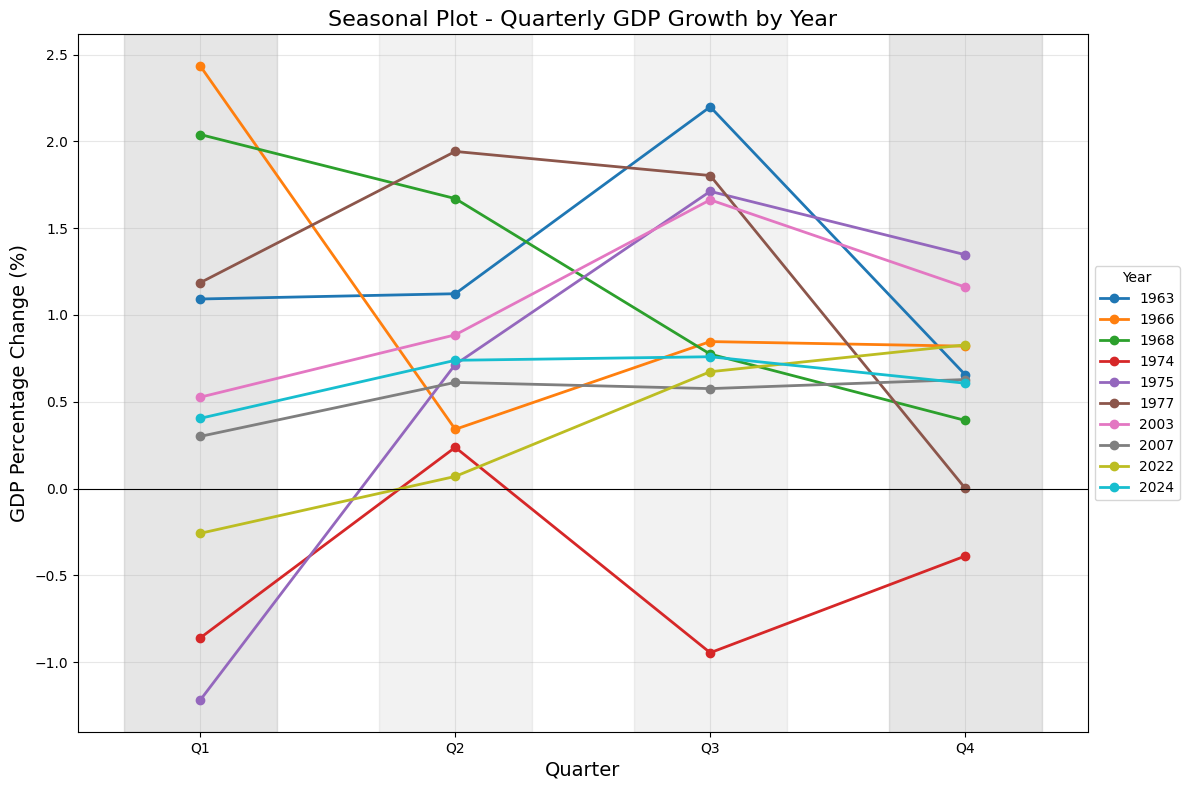

Selected years and quarterly GDP growth rates:
Quarter         1         2         3         4
Year                                           
1963     1.092090  1.122414  2.198831  0.655905
1966     2.433835  0.341470  0.846833  0.820403
1968     2.039271  1.670373  0.774519  0.392774
1974    -0.859705  0.237697 -0.945277 -0.388406
1975    -1.217634  0.714701  1.712045  1.347093
1977     1.186233  1.941924  1.803165  0.001993
2003     0.526642  0.885622  1.663200  1.160721
2007     0.300836  0.611762  0.576026  0.628237
2022    -0.257454  0.070179  0.673208  0.827828
2024     0.404802  0.738980  0.759510  0.607065


In [11]:
# Create a seasonal plot for quarterly GDP growth (percentage change)
import numpy as np
import matplotlib.pyplot as plt
import random

# Prepare data for the plot
gdp_seasonal_pct = gdp_series.reset_index()
gdp_seasonal_pct['Year'] = gdp_seasonal_pct['sasdate'].dt.year
gdp_seasonal_pct['Quarter'] = gdp_seasonal_pct['sasdate'].dt.quarter

# Create a pivot table with years as rows and quarters as columns for GDP_Change (percentage)
gdp_change_pivot = gdp_seasonal_pct.pivot(index='Year', columns='Quarter', values='GDP_Change')

# Select 10 random years for better visualization
# Exclude the first year (1959) as it has NaN for Q1
available_years = list(gdp_change_pivot.index)[1:]
# Set random seed for reproducibility
random.seed(42)
selected_years = sorted(random.sample(available_years, 10))
selected_data = gdp_change_pivot.loc[selected_years]

# Create the plot
plt.figure(figsize=(12, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(selected_years)))

# Plot each year
for i, year in enumerate(selected_years):
    # Convert percentage to more readable values (multiply by 100)
    plt.plot(range(1, 5), selected_data.loc[year] * 100, 
             marker='o', linewidth=2, color=colors[i], label=str(year))

# Highlight recession periods with vertical shaded areas
# For the seasonal plot, we'll shade the quarters that had recessions in the selected years
for year in selected_years:
    for start, end in recessions:
        if start.year <= year <= end.year:
            # Determine which quarters were in recession for this year
            for q in range(1, 5):
                quarter_start = pd.Timestamp(f"{year}-{3*q-2}-01")
                quarter_end = pd.Timestamp(f"{year}-{3*q}-01") + pd.offsets.MonthEnd(1)
                
                # Check if this quarter overlaps with recession
                if (start <= quarter_end and end >= quarter_start):
                    plt.axvspan(q-0.3, q+0.3, color='gray', alpha=0.1)

# Add grid and customize appearance
plt.grid(True, alpha=0.3)
plt.title('Seasonal Plot - Quarterly GDP Growth by Year', fontsize=16)
plt.xlabel('Quarter', fontsize=14)
plt.ylabel('GDP Percentage Change (%)', fontsize=14)
plt.xticks([1, 2, 3, 4], ['Q1', 'Q2', 'Q3', 'Q4'])
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)  # Add line at y=0

# Add legend with smaller font size for better readability
plt.legend(title='Year', loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)

# Add text annotations for extreme values
for year in selected_years:
    for q in range(1, 5):
        # Only annotate significant values (above 3% or below -3%)
        value = selected_data.loc[year, q] * 100
        if abs(value) > 3:
            plt.annotate(f"{value:.1f}%", 
                        (q, value),
                        textcoords="offset points", 
                        xytext=(0, 10 if value > 0 else -15), 
                        ha='center',
                        fontsize=8)

plt.tight_layout()
plt.show()

# Print the selected years and their quarterly growth rates for reference
print("Selected years and quarterly GDP growth rates:")
print(selected_data * 100)  # Multiply by 100 to display as percentage

Which features are highly correlated with GDP?

Summary statistics by quarter:
         count      mean       std       min       25%       50%       75%  \
Quarter                                                                      
1         65.0  0.768139  0.955809 -1.553645  0.319842  0.813410  1.197252   
2         66.0  0.690936  1.344896 -7.908965  0.383811  0.724038  1.114078   
3         66.0  0.884603  1.076984 -0.945277  0.493788  0.805485  1.145382   
4         66.0  0.654774  0.814957 -2.189027  0.277327  0.702241  1.113468   

              max  
Quarter            
1        2.716149  
2        3.864773  
3        7.830225  
4        2.303902  

Percentage of quarters with negative growth:
Q1.0: 18.2%
Q2.0: 7.6%
Q3.0: 10.6%
Q4.0: 10.6%

Percentage of quarters in recession:
Q1.0: 16.7%
Q2.0: 13.6%
Q3.0: 13.6%
Q4.0: 16.7%


C:\Users\giada\AppData\Local\Temp\ipykernel_9324\3113883050.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Quarter', y='Growth_Rate', data=gdp_change_long,


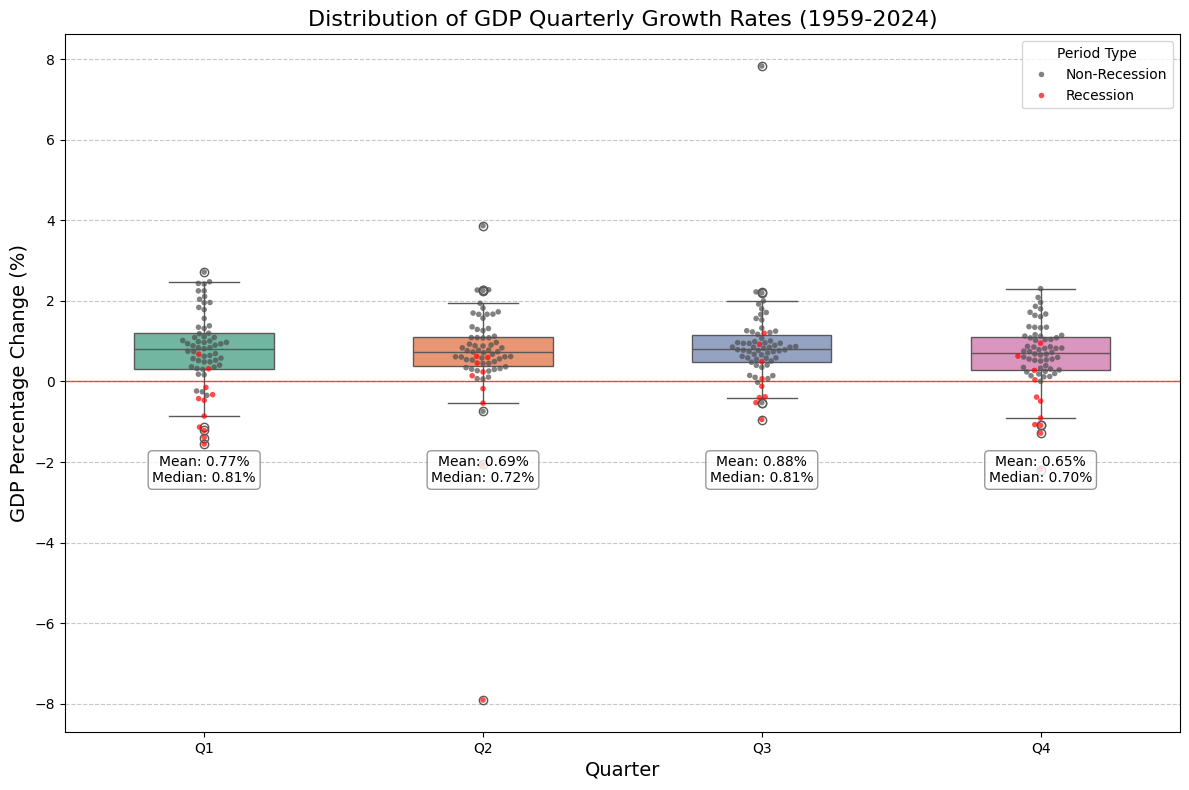

In [12]:
# Create boxplots showing distribution of GDP growth by quarter across all years
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Reshape the pivot table to a format suitable for boxplot
# We'll use all available years (not just the 10 random ones from previous plot)
gdp_change_long = gdp_change_pivot.reset_index().melt(
    id_vars=['Year'], 
    value_vars=[1, 2, 3, 4],
    var_name='Quarter', 
    value_name='Growth_Rate'
)

# Convert to percentage for better readability
gdp_change_long['Growth_Rate'] = gdp_change_long['Growth_Rate'] * 100

# Identify which quarter-year combinations were in recession periods
gdp_change_long['In_Recession'] = False

for idx, row in gdp_change_long.iterrows():
    year = row['Year']
    quarter = row['Quarter']
    # Create start and end date for this quarter
    quarter_start = pd.Timestamp(f"{year}-{3*quarter-2}-01")
    quarter_end = pd.Timestamp(f"{year}-{3*quarter}-01") + pd.offsets.MonthEnd(1)
    
    # Check if this quarter overlaps with any recession period
    for start, end in recessions:
        if (start <= quarter_end and end >= quarter_start):
            gdp_change_long.at[idx, 'In_Recession'] = True
            break

# Create a figure with boxplots
plt.figure(figsize=(12, 8))

# Use seaborn for boxplots with data points overlaid
ax = sns.boxplot(x='Quarter', y='Growth_Rate', data=gdp_change_long, 
                palette='Set2', width=0.5)

# Add individual data points, coloring by recession status
sns.swarmplot(x='Quarter', y='Growth_Rate', data=gdp_change_long, 
              hue='In_Recession', palette={False: '0.3', True: 'red'}, 
              alpha=0.7, size=4, dodge=False)

# Add a horizontal line at y=0 to indicate no growth
plt.axhline(y=0, color='red', linestyle='-', linewidth=1, alpha=0.7)

# Customize the plot
plt.title('Distribution of GDP Quarterly Growth Rates (1959-2024)', fontsize=16)
plt.xlabel('Quarter', fontsize=14)
plt.ylabel('GDP Percentage Change (%)', fontsize=14)
plt.xticks([0, 1, 2, 3], ['Q1', 'Q2', 'Q3', 'Q4'])
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Add legend for recession points
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['Non-Recession', 'Recession'], title='Period Type')

# Add statistics as text annotations
for i, quarter in enumerate([1, 2, 3, 4]):
    quarter_data = gdp_change_long[gdp_change_long['Quarter'] == quarter]['Growth_Rate']
    mean_val = quarter_data.mean()
    median_val = quarter_data.median()
    
    # Add mean and median text
    plt.annotate(f"Mean: {mean_val:.2f}%\nMedian: {median_val:.2f}%",
                xy=(i, -2.5), 
                ha='center', 
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
    
# Calculate overall statistics for reference
print("Summary statistics by quarter:")
summary_stats = gdp_change_long.groupby('Quarter')['Growth_Rate'].describe()
print(summary_stats)

# Count negative quarters by quarter number
negative_counts = gdp_change_long[gdp_change_long['Growth_Rate'] < 0].groupby('Quarter').size()
total_quarters = gdp_change_long.groupby('Quarter').size()
negative_pct = (negative_counts / total_quarters * 100).reset_index()
negative_pct.columns = ['Quarter', 'Negative_Pct']

print("\nPercentage of quarters with negative growth:")
for i, row in negative_pct.iterrows():
    print(f"Q{row['Quarter']}: {row['Negative_Pct']:.1f}%")

# Count recession quarters by quarter number
recession_counts = gdp_change_long[gdp_change_long['In_Recession']].groupby('Quarter').size()
recession_pct = (recession_counts / total_quarters * 100).reset_index()
recession_pct.columns = ['Quarter', 'Recession_Pct']

print("\nPercentage of quarters in recession:")
for i, row in recession_pct.iterrows():
    print(f"Q{row['Quarter']}: {row['Recession_Pct']:.1f}%")

plt.tight_layout()
plt.show()

C:\Users\giada\AppData\Local\Temp\ipykernel_9324\3701824452.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Quarter', y='Growth_Rate', data=filtered_data,


Summary statistics by quarter (after removing extreme outliers):
         count      mean       std       min       25%       50%       75%  \
Quarter                                                                      
1         65.0  0.768139  0.955809 -1.553645  0.319842  0.813410  1.197252   
2         65.0  0.823242  0.814635 -2.060435  0.446335  0.733374  1.122414   
3         65.0  0.777748  0.642374 -0.945277  0.489931  0.788524  1.071523   
4         66.0  0.654774  0.814957 -2.189027  0.277327  0.702241  1.113468   

              max  
Quarter            
1        2.716149  
2        3.864773  
3        2.223160  
4        2.303902  

Percentage of quarters with negative growth (after removing outliers):
Q1.0: 18.5%
Q2.0: 6.2%
Q3.0: 10.8%
Q4.0: 10.6%

Number of outliers removed by quarter:
Q1: 1 outliers removed
Q2: 1 outliers removed
Q3: 1 outliers removed
Q4: 0 outliers removed


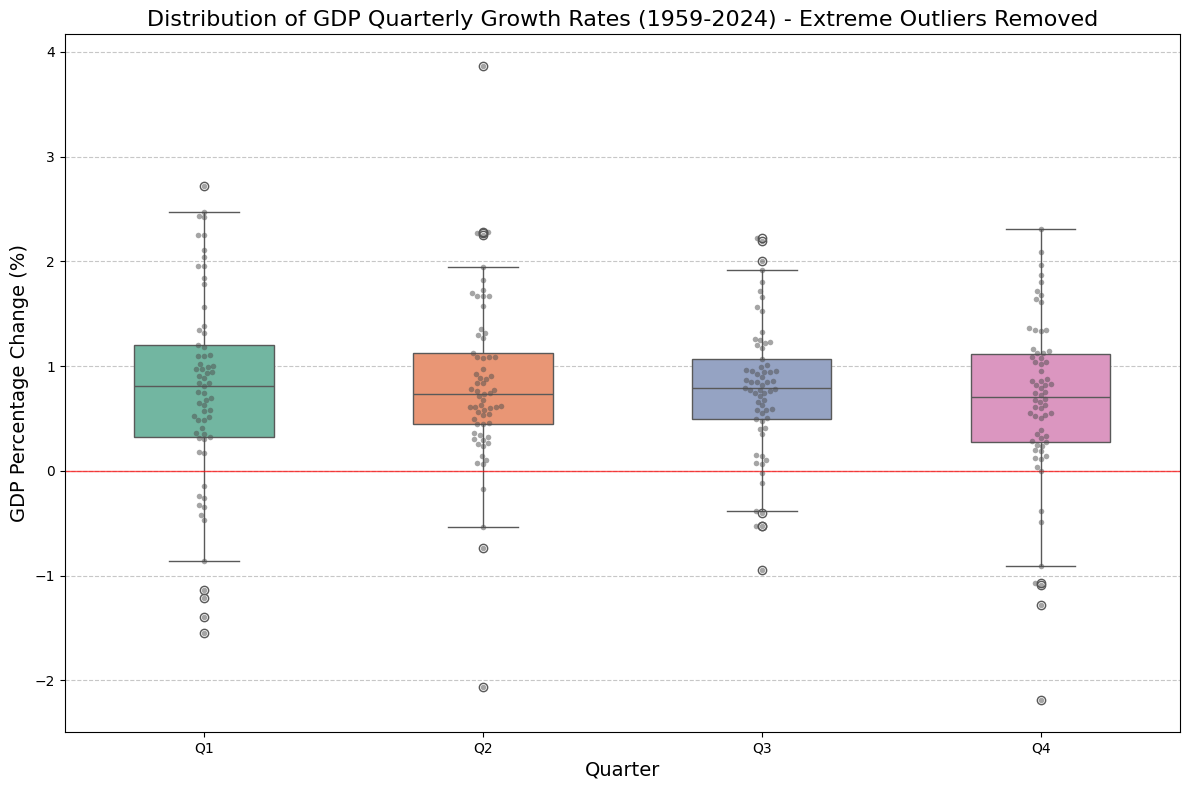

In [13]:
import seaborn as sns
import pandas as pd
import numpy as np

# Create boxplots showing distribution of GDP growth by quarter across all years (with outlier removal)
import matplotlib.pyplot as plt

# Reshape the pivot table to a format suitable for boxplot
gdp_change_long = gdp_change_pivot.reset_index().melt(
    id_vars=['Year'], 
    value_vars=[1, 2, 3, 4],
    var_name='Quarter', 
    value_name='Growth_Rate'
)

# Convert to percentage for better readability
gdp_change_long['Growth_Rate'] = gdp_change_long['Growth_Rate'] * 100

# Remove extreme outliers (values outside 10*IQR) for each quarter
filtered_data = pd.DataFrame()
for quarter in [1, 2, 3, 4]:
    quarter_data = gdp_change_long[gdp_change_long['Quarter'] == quarter]
    
    # Calculate IQR and bounds
    Q1 = quarter_data['Growth_Rate'].quantile(0.25)
    Q3 = quarter_data['Growth_Rate'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 10 * IQR
    upper_bound = Q3 + 10 * IQR
    
    # Filter out extreme outliers
    quarter_filtered = quarter_data[(quarter_data['Growth_Rate'] >= lower_bound) & 
                                  (quarter_data['Growth_Rate'] <= upper_bound)]
    
    # Add to the filtered dataframe
    filtered_data = pd.concat([filtered_data, quarter_filtered])

# Create a figure with boxplots
plt.figure(figsize=(12, 8))

# Use seaborn for nicer boxplots with data points overlaid
ax = sns.boxplot(x='Quarter', y='Growth_Rate', data=filtered_data, 
                palette='Set2', width=0.5)

# Add individual data points (swarmplot)
sns.swarmplot(x='Quarter', y='Growth_Rate', data=filtered_data, 
              color='0.3', alpha=0.5, size=4)

# Add a horizontal line at y=0 to indicate no growth
plt.axhline(y=0, color='red', linestyle='-', linewidth=1, alpha=0.7)

# Customize the plot
plt.title('Distribution of GDP Quarterly Growth Rates (1959-2024) - Extreme Outliers Removed', fontsize=16)
plt.xlabel('Quarter', fontsize=14)
plt.ylabel('GDP Percentage Change (%)', fontsize=14)
plt.xticks([0, 1, 2, 3], ['Q1', 'Q2', 'Q3', 'Q4'])
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Add statistics as text annotations
for i, quarter in enumerate([1, 2, 3, 4]):
    quarter_data = filtered_data[filtered_data['Quarter'] == quarter]['Growth_Rate']
    mean_val = quarter_data.mean()
    median_val = quarter_data.median()
    
    # Add mean and median text
    plt.annotate(f"Mean: {mean_val:.2f}%\nMedian: {median_val:.2f}%",
                xy=(i, -2.5), 
                ha='center', 
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
    
# Calculate and print summary statistics by quarter
print("Summary statistics by quarter (after removing extreme outliers):")
summary_stats = filtered_data.groupby('Quarter')['Growth_Rate'].describe()
print(summary_stats)

# Count negative quarters by quarter number
negative_counts = filtered_data[filtered_data['Growth_Rate'] < 0].groupby('Quarter').size()
total_quarters = filtered_data.groupby('Quarter').size()
negative_pct = (negative_counts / total_quarters * 100).reset_index()
negative_pct.columns = ['Quarter', 'Negative_Pct']

print("\nPercentage of quarters with negative growth (after removing outliers):")
for i, row in negative_pct.iterrows():
    print(f"Q{row['Quarter']}: {row['Negative_Pct']:.1f}%")

# Print information about removed outliers
original_counts = gdp_change_long.groupby('Quarter').size()
filtered_counts = filtered_data.groupby('Quarter').size()
removed_counts = original_counts - filtered_counts

print("\nNumber of outliers removed by quarter:")
for quarter in [1, 2, 3, 4]:
    if quarter in removed_counts:
        print(f"Q{quarter}: {removed_counts[quarter]} outliers removed")
    else:
        print(f"Q{quarter}: 0 outliers removed")

plt.tight_layout()
plt.show()

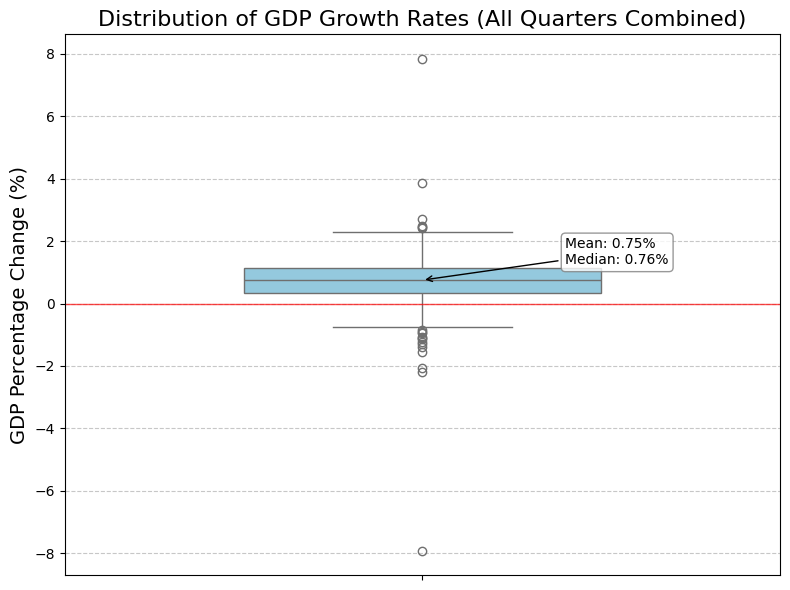

Summary statistics for GDP growth rates (all quarters combined):
count    263.000000
mean       0.749543
std        1.064066
min       -7.908965
25%        0.349869
50%        0.759510
75%        1.136308
max        7.830225
Name: Growth_Rate, dtype: float64


In [14]:
import seaborn as sns

import matplotlib.pyplot as plt

# Combine all quarters into a single dataset for boxplot
gdp_change_all = gdp_change_long['Growth_Rate']

# Create the boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=gdp_change_all, color='skyblue', width=0.5)

# Add a horizontal line at y=0 to indicate no growth
plt.axhline(y=0, color='red', linestyle='-', linewidth=1, alpha=0.7)

# Customize the plot
plt.title('Distribution of GDP Growth Rates (All Quarters Combined)', fontsize=16)
plt.ylabel('GDP Percentage Change (%)', fontsize=14)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Add statistics as text annotations
mean_val = gdp_change_all.mean()
median_val = gdp_change_all.median()

plt.annotate(f"Mean: {mean_val:.2f}%\nMedian: {median_val:.2f}%",
             xy=(0, mean_val), 
             xytext=(0.2, mean_val + 0.5), 
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Display the plot
plt.tight_layout()
plt.show()

# Print summary statistics for reference
print("Summary statistics for GDP growth rates (all quarters combined):")
print(gdp_change_all.describe())

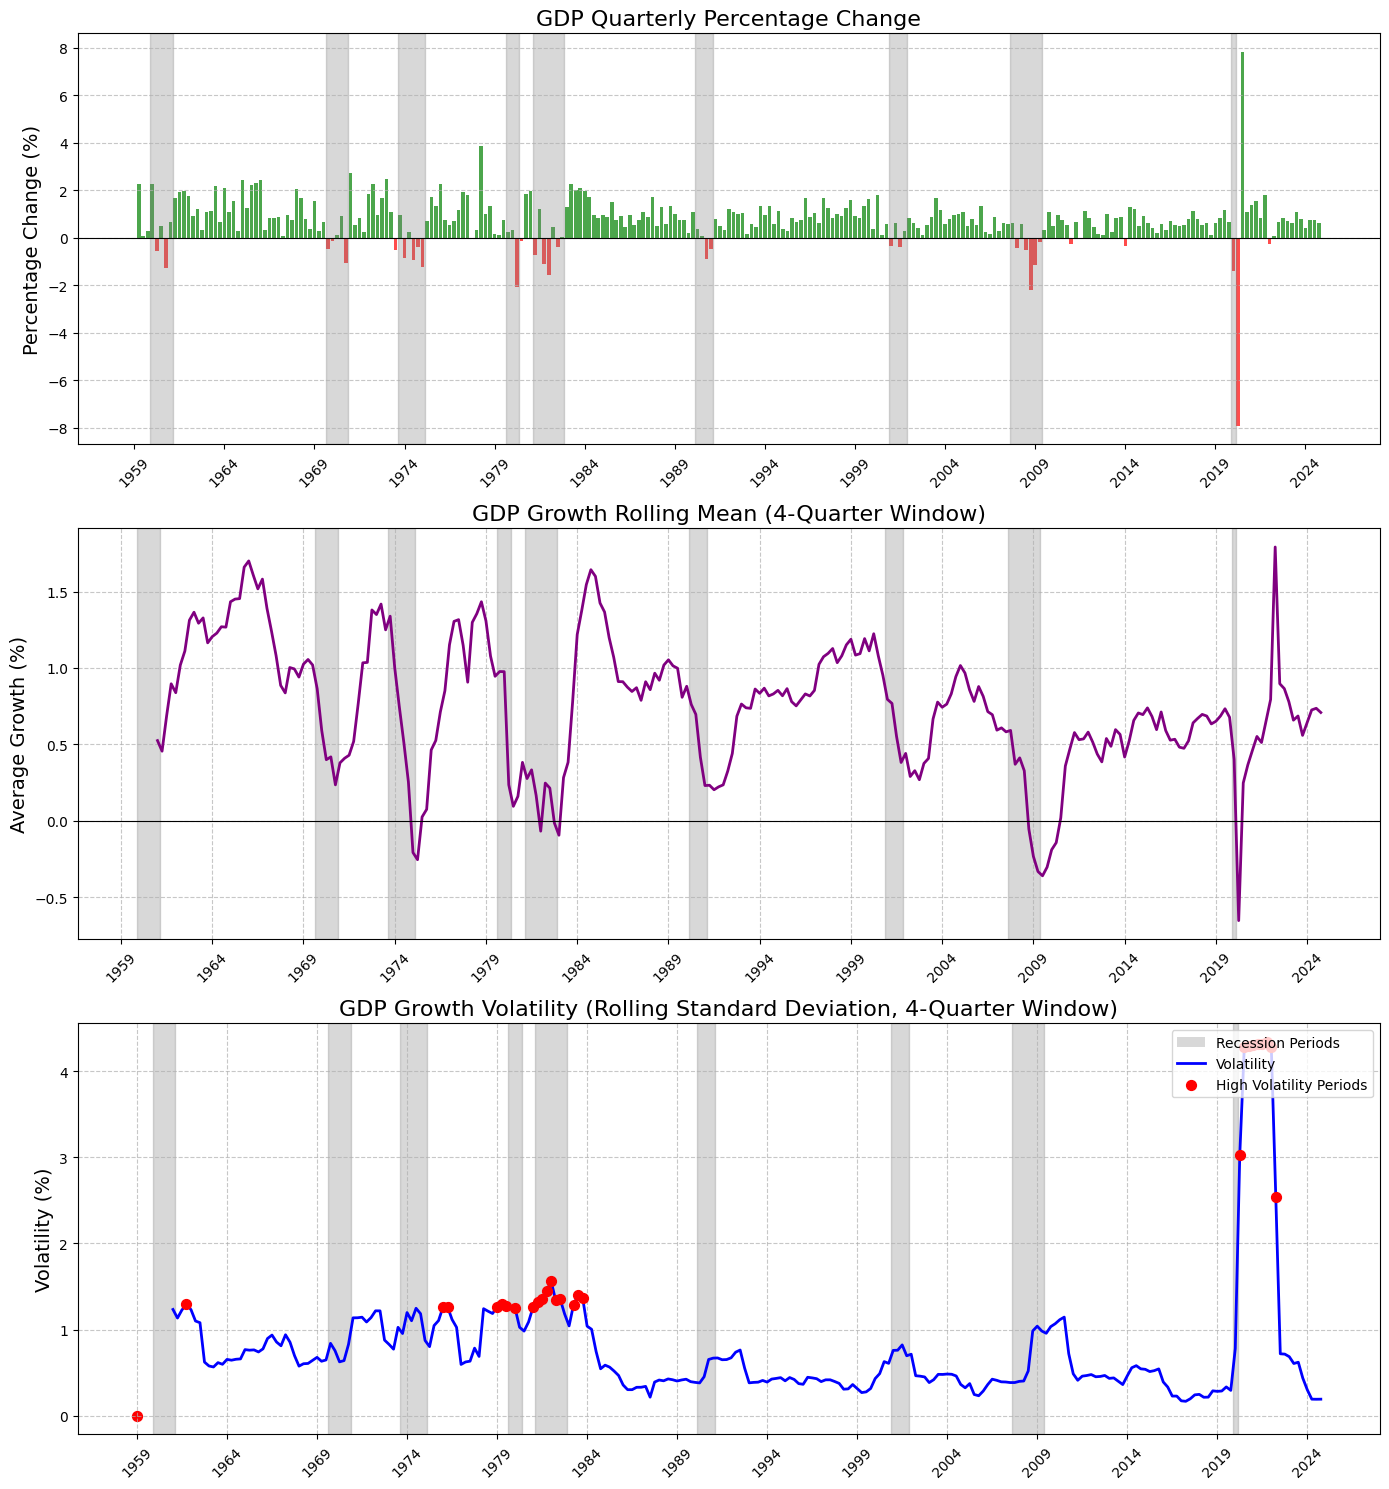

GDP Growth Volatility Summary Statistics (in percentage):
count    256.000000
mean       0.778372
std        0.703247
min        0.166116
25%        0.403682
50%        0.604062
75%        0.983466
max        4.341208
Name: GDP_Volatility, dtype: float64

GDP Growth Rolling Mean Summary Statistics (in percentage):
count    256.000000
mean       0.748588
std        0.423518
min       -0.653090
25%        0.480059
50%        0.762462
75%        1.020889
max        1.791739
Name: GDP_Rolling_Mean, dtype: float64

Top 5 Periods of Highest GDP Growth Volatility:
2021-12-01: 4.34%
2021-06-01: 4.32%
2021-09-01: 4.32%
2021-03-01: 4.30%
2020-12-01: 4.29%


In [15]:
# Calculate GDP volatility using rolling standard deviation and rolling mean
window_size = 8  # 1 year (4 quarters)

# First, calculate GDP percentage change from GDPC1
gdp_series['GDP_Change'] = gdp_series['GDPC1'].pct_change()

# Then calculate rolling statistics
gdp_series['GDP_Volatility'] = gdp_series['GDP_Change'].rolling(window=window_size).std()
gdp_series['GDP_Rolling_Mean'] = gdp_series['GDP_Change'].rolling(window=window_size).mean()

# Create a plot to visualize the GDP percentage change, volatility, and rolling mean
plt.figure(figsize=(14, 15))

# Define recession periods if they haven't been defined already
if 'recessions' not in locals():
    recessions = [
        ('1960-05-01', '1961-02-01'),
        ('1970-01-01', '1970-11-01'),
        ('1973-12-01', '1975-03-01'),
        ('1980-02-01', '1980-07-01'),
        ('1981-08-01', '1982-11-01'),
        ('1990-08-01', '1991-03-01'),
        ('2001-04-01', '2001-11-01'),
        ('2008-01-01', '2009-06-01'),
        ('2020-03-01', '2020-04-01')
    ]
    # Convert recession dates to datetime
    recessions = [(pd.to_datetime(start), pd.to_datetime(end)) for start, end in recessions]

# Plot 1: GDP percentage change
ax1 = plt.subplot(3, 1, 1)
plt.bar(range(len(gdp_series)), gdp_series['GDP_Change'] * 100, 
    color=gdp_series['GDP_Change'].apply(lambda x: 'red' if x < 0 else 'green'),
    alpha=0.7, width=0.8)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.title('GDP Quarterly Percentage Change', fontsize=16)
plt.ylabel('Percentage Change (%)', fontsize=14)

# Shade recession periods
for start, end in recessions:
    try:
        # Find positions in the index
        start_idx = gdp_series.index.get_indexer([start], method='nearest')[0]
        end_idx = gdp_series.index.get_indexer([end], method='nearest')[0]
        
        # Add shaded area
        ax1.axvspan(start_idx-0.5, end_idx+0.5, color='gray', alpha=0.3)
    except:
        print(f"Could not shade recession period {start} to {end}")

# Set x-axis ticks to show years at regular intervals
step = 20
tick_positions = list(range(0, len(gdp_series), step))
plt.xticks(tick_positions, [gdp_series.index[i].strftime('%Y') for i in tick_positions], rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Plot 2: GDP rolling mean (4-quarter)
ax2 = plt.subplot(3, 1, 2)
plt.plot(range(len(gdp_series)), gdp_series['GDP_Rolling_Mean'] * 100, color='purple', linewidth=2)
plt.title('GDP Growth Rolling Mean (4-Quarter Window)', fontsize=16)
plt.ylabel('Average Growth (%)', fontsize=14)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

# Shade recession periods
for start, end in recessions:
    try:
        # Find positions in the index
        start_idx = gdp_series.index.get_indexer([start], method='nearest')[0]
        end_idx = gdp_series.index.get_indexer([end], method='nearest')[0]
        
        # Add shaded area
        ax2.axvspan(start_idx-0.5, end_idx+0.5, color='gray', alpha=0.3)
    except:
        print(f"Could not shade recession period {start} to {end}")

plt.xticks(tick_positions, [gdp_series.index[i].strftime('%Y') for i in tick_positions], rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

# Plot 3: GDP volatility (rolling standard deviation)
ax3 = plt.subplot(3, 1, 3)
plt.plot(range(len(gdp_series)), gdp_series['GDP_Volatility'] * 100, color='blue', linewidth=2)
plt.title('GDP Growth Volatility (Rolling Standard Deviation, 4-Quarter Window)', fontsize=16)
plt.ylabel('Volatility (%)', fontsize=14)

# Shade recession periods
for start, end in recessions:
    try:
        # Find positions in the index
        start_idx = gdp_series.index.get_indexer([start], method='nearest')[0]
        end_idx = gdp_series.index.get_indexer([end], method='nearest')[0]
        
        # Add shaded area
        ax3.axvspan(start_idx-0.5, end_idx+0.5, color='gray', alpha=0.3)
    except:
        print(f"Could not shade recession period {start} to {end}")

plt.xticks(tick_positions, [gdp_series.index[i].strftime('%Y') for i in tick_positions], rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

# Highlight periods of high volatility (top 10%)
high_volatility_threshold = gdp_series['GDP_Volatility'].quantile(0.9)
high_volatility_periods = gdp_series[gdp_series['GDP_Volatility'] > high_volatility_threshold]
plt.scatter(
    [gdp_series.index.get_loc(date) for date in high_volatility_periods.index],
    high_volatility_periods['GDP_Volatility'] * 100,
    color='red', s=50, zorder=5
)

# Add legend for recession periods
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='gray', alpha=0.3, label='Recession Periods'),
    plt.Line2D([0], [0], color='blue', lw=2, label='Volatility'),
    plt.scatter([0], [0], color='red', s=50, label='High Volatility Periods')
]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# Display summary statistics for GDP volatility and rolling mean
print("GDP Growth Volatility Summary Statistics (in percentage):")
volatility_stats = gdp_series['GDP_Volatility'].dropna() * 100
print(volatility_stats.describe())

print("\nGDP Growth Rolling Mean Summary Statistics (in percentage):")
rolling_mean_stats = gdp_series['GDP_Rolling_Mean'].dropna() * 100
print(rolling_mean_stats.describe())

# Identify the top 5 periods of highest volatility
print("\nTop 5 Periods of Highest GDP Growth Volatility:")
top_volatility = gdp_series.sort_values('GDP_Volatility', ascending=False).head(5)
for date, row in top_volatility.iterrows():
    print(f"{date.strftime('%Y-%m-%d')}: {row['GDP_Volatility']*100:.2f}%")

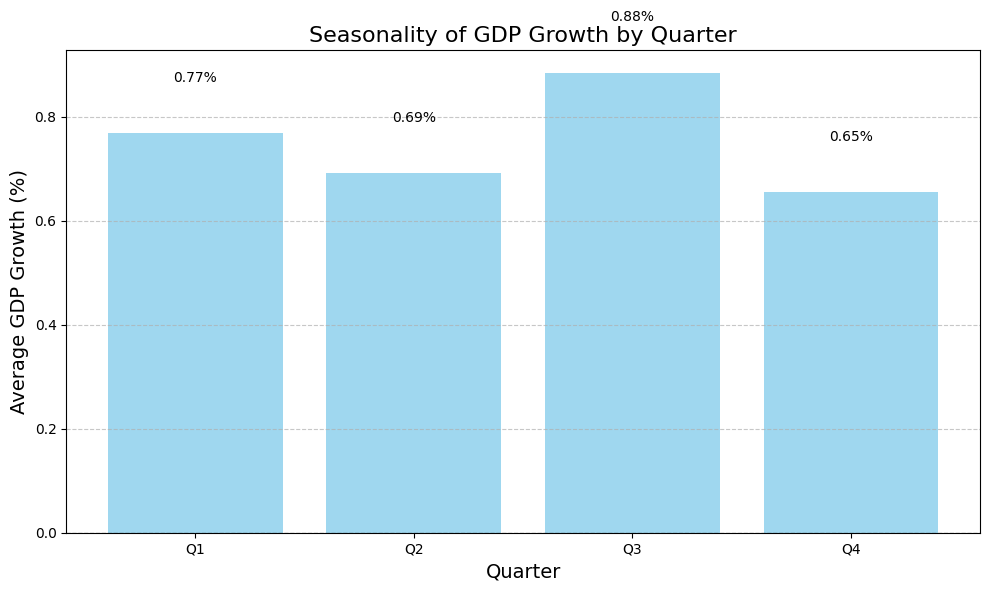

Average GDP Growth by Quarter (%):
Quarter
1    0.768139
2    0.690936
3    0.884603
4    0.654774
Name: GDP_Change, dtype: float64


In [16]:
import pandas as pd

import matplotlib.pyplot as plt

# Group GDP growth by quarter and calculate the mean for each quarter
seasonality = gdp_seasonal_pct.groupby('Quarter')['GDP_Change'].mean() * 100  # Convert to percentage

# Plot the seasonal pattern
plt.figure(figsize=(10, 6))
plt.bar(seasonality.index, seasonality, color='skyblue', alpha=0.8)

# Customize the plot
plt.title('Seasonality of GDP Growth by Quarter', fontsize=16)
plt.xlabel('Quarter', fontsize=14)
plt.ylabel('Average GDP Growth (%)', fontsize=14)
plt.xticks([1, 2, 3, 4], ['Q1', 'Q2', 'Q3', 'Q4'])
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)  # Add a horizontal line at y=0
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate the bars with the average values
for quarter, value in seasonality.items():
    plt.text(quarter, value + 0.1 if value > 0 else value - 0.5, f"{value:.2f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Print the seasonal averages for reference
print("Average GDP Growth by Quarter (%):")
print(seasonality)

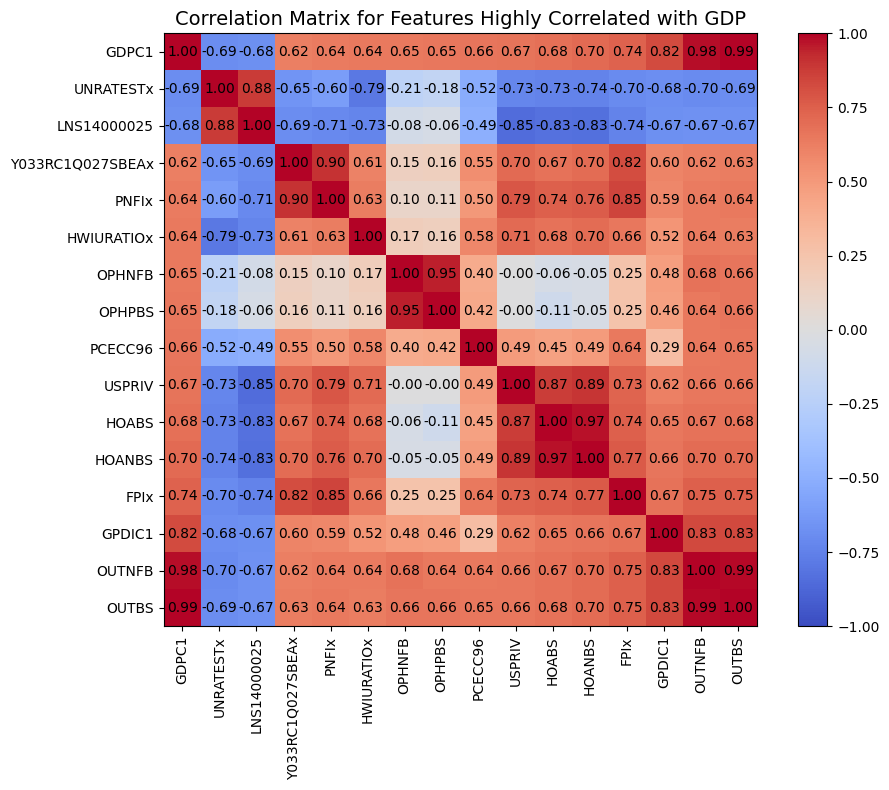

Features with high correlation (abs > 0.90) with GDP:
UNRATESTx          -0.693032
LNS14000025        -0.677092
Y033RC1Q027SBEAx    0.621808
PNFIx               0.640592
HWIURATIOx          0.642368
OPHNFB              0.647136
OPHPBS              0.648936
PCECC96             0.657198
USPRIV              0.667670
HOABS               0.681147
HOANBS              0.704208
FPIx                0.737363
GPDIC1              0.821180
OUTNFB              0.981808
OUTBS               0.994626
Name: GDPC1, dtype: float64


In [17]:
# Load train data which returns a tuple of DataFrames
data = load_train_data()
# Access the correct DataFrame (second element of the tuple that contains GDPC1)
gdp_data = data[1]  # Using the second DataFrame which contains GDPC1
# Calculate correlation with GDP
correlation_with_gdp = gdp_data.corr()['GDPC1'].sort_values()

# Filter for high correlations (absolute value >0.90) excluding GDPC1 itself
high_correlations_positive = correlation_with_gdp[(correlation_with_gdp > 0.60) & (correlation_with_gdp < 1.0)]
high_correlations_negative = correlation_with_gdp[correlation_with_gdp < -0.60]
high_correlations = pd.concat([high_correlations_negative, high_correlations_positive])

# Create a correlation matrix for these highly correlated features
if len(high_correlations) > 0:
    highly_correlated_features = list(high_correlations.index)
    # Add GDPC1 to the list
    features_to_include = ['GDPC1'] + highly_correlated_features
    
    # Create correlation matrix
    high_corr_matrix = gdp_data[features_to_include].corr()
    
    # Plot the correlation matrix
    plt.figure(figsize=(10, 8))
    plt.title('Correlation Matrix for Features Highly Correlated with GDP', fontsize=14)
    heatmap = plt.imshow(high_corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar(heatmap)
    
    # Add correlation values
    for i in range(len(features_to_include)):
        for j in range(len(features_to_include)):
            text = plt.text(j, i, f"{high_corr_matrix.iloc[i, j]:.2f}",
                           ha="center", va="center", color="black")
    
    plt.xticks(range(len(features_to_include)), features_to_include, rotation=90)
    plt.yticks(range(len(features_to_include)), features_to_include)
    plt.tight_layout()
    plt.show()
    
    print("Features with high correlation (abs > 0.90) with GDP:")
    print(high_correlations)
else:
    print("No features found with correlation magnitude > 0.90")

Top 30 Feature-Lag Combinations Correlated with GDP (Lag > 0):
                 Feature  Lag  Correlation  Abs_Correlation
2570        IPMANSICS_m2    1     0.735877         0.735877
2470           INDPRO_m2    1     0.734730         0.734730
1260           INDPRO_m1    1     0.710360         0.710360
2450        CMRMTSPLx_m2    1     0.700079         0.700079
2480          IPFPNSS_m2    1     0.699978         0.699978
2600           CUMFNS_m2    1     0.699150         0.699150
1270          IPFPNSS_m1    1     0.698794         0.698794
2540            IPMAT_m2    1     0.695499         0.695499
1360        IPMANSICS_m1    1     0.689201         0.689201
2490          IPFINAL_m2    1     0.675376         0.675376
2740           USGOOD_m2    1     0.674837         0.674837
1280          IPFINAL_m1    1     0.674149         0.674149
1330            IPMAT_m1    1     0.666436         0.666436
1240        CMRMTSPLx_m1    1     0.663156         0.663156
2550           IPDMAT_m2    1     0.6

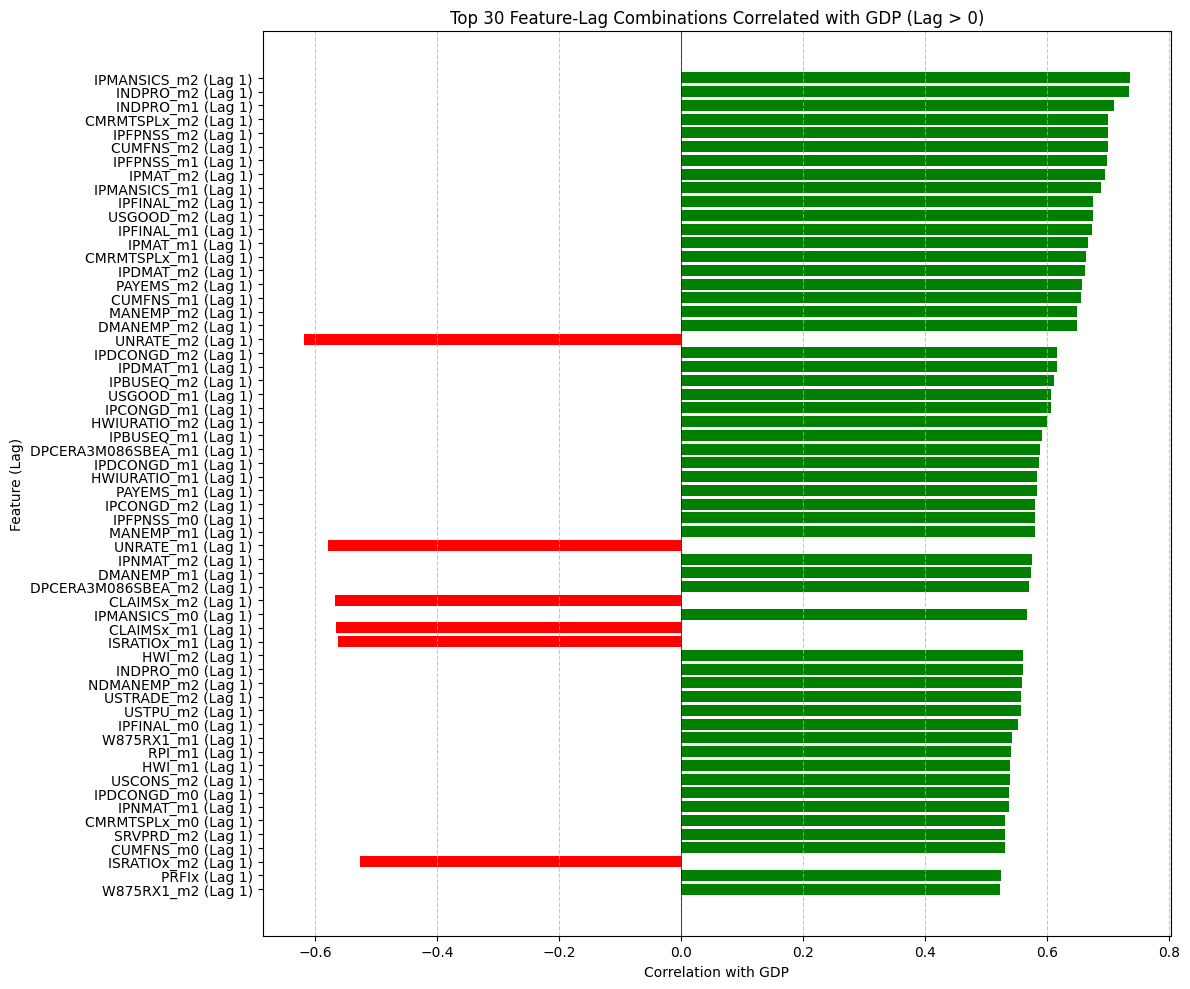

In [36]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import ccf


monthly_0 = pd.read_csv("FRED_md_train_monthly_averaged_lookahead=0months.csv", 
                        parse_dates=['date'],
                        index_col='date',
                        date_format='%Y-%m-%d')
monthly_1 = pd.read_csv("FRED_md_train_monthly_averaged_lookahead=1months.csv",
                        parse_dates=['date'],
                        index_col='date',
                        date_format='%Y-%m-%d')
monthly_2 = pd.read_csv("FRED_md_train_monthly_averaged_lookahead=2months.csv",
                        parse_dates=['date'],   
                        index_col='date',
                        date_format='%Y-%m-%d')

# rename columns to include lookahead in the name
monthly_0.columns = [f"{col}_m0" for col in monthly_0.columns]
monthly_1.columns = [f"{col}_m1" for col in monthly_1.columns]
monthly_2.columns = [f"{col}_m2" for col in monthly_2.columns]

data = load_train_data()
fred_md_train = data[1]

# Combine the monthly data into a single DataFrame
all_data = pd.concat([monthly_0, monthly_1, monthly_2, fred_md_train], axis=1)

# Make sure we have GDPC1 in the dataset
if 'GDPC1' not in all_data.columns:
    print("GDPC1 not found in dataset. Using data from fred_md_train instead.")
    # Add GDPC1 to the combined dataset
    all_data['GDPC1'] = fred_md_train['GDPC1']

# Function to calculate cross-correlation with lags (skipping lag 0)
def calculate_cross_correlations(df, target_col, max_lag=6):
    results = []
    
    # Get the target series (GDP)
    target_series = df[target_col].dropna()
    
    # Loop through all columns except the target
    for col in df.columns:
        if col == target_col:
            continue
            
        # Get the feature series
        feature_series = df[col].dropna()
        
        # Align the series by their indices
        common_idx = target_series.index.intersection(feature_series.index)
        if len(common_idx) < max_lag + 1:
            continue
            
        aligned_target = target_series.loc[common_idx]
        aligned_feature = feature_series.loc[common_idx]
        
        # Calculate cross-correlation at different lags (skipping lag 0)
        for lag in range(1, max_lag + 1):
            try:
                # Calculate cross-correlation
                correlation = ccf(aligned_target, aligned_feature, adjusted=False)[lag]
                results.append({
                    'Feature': col,
                    'Lag': lag,
                    'Correlation': correlation,
                    'Abs_Correlation': abs(correlation)
                })
            except:
                print(f"Error calculating correlation for {col} at lag {lag}")
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    return results_df

# Calculate cross-correlations with lags 1 to 6 (skipping lag 0)
cross_corr_results = calculate_cross_correlations(all_data, 'GDPC1', max_lag=10)

# Sort by absolute correlation and get top 30
top_correlations = cross_corr_results.sort_values('Abs_Correlation', ascending=False).head(60)
# reverse order


# Display the top correlations
print("Top 30 Feature-Lag Combinations Correlated with GDP (Lag > 0):")
print(top_correlations[['Feature', 'Lag', 'Correlation', 'Abs_Correlation']])

# Create a bar plot of the top correlations
plt.figure(figsize=(12, 10))
# Reverse the order to display highest correlations at the top
top_correlations_reversed = top_correlations.iloc[::-1]
bars = plt.barh(
    y=[f"{row['Feature']} (Lag {row['Lag']})" for _, row in top_correlations_reversed.iterrows()],
    width=top_correlations_reversed['Correlation'],
    color=top_correlations_reversed['Correlation'].apply(lambda x: 'green' if x > 0 else 'red')
)
plt.xlabel('Correlation with GDP')
plt.ylabel('Feature (Lag)')
plt.title('Top 30 Feature-Lag Combinations Correlated with GDP (Lag > 0)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

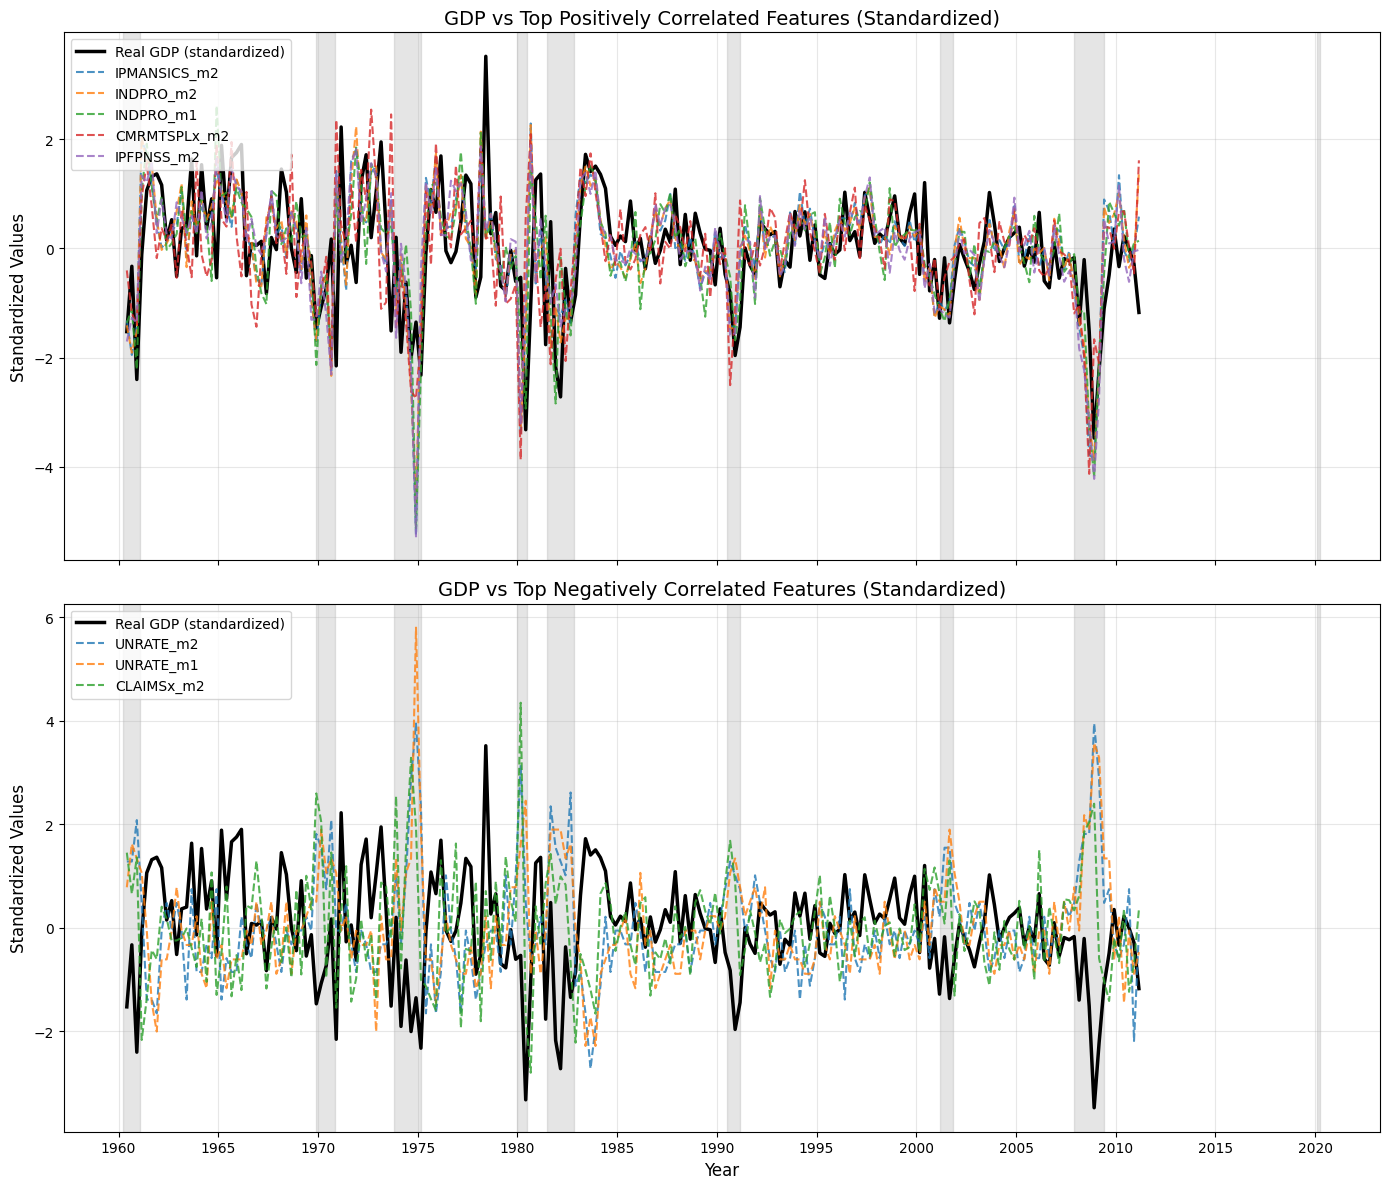

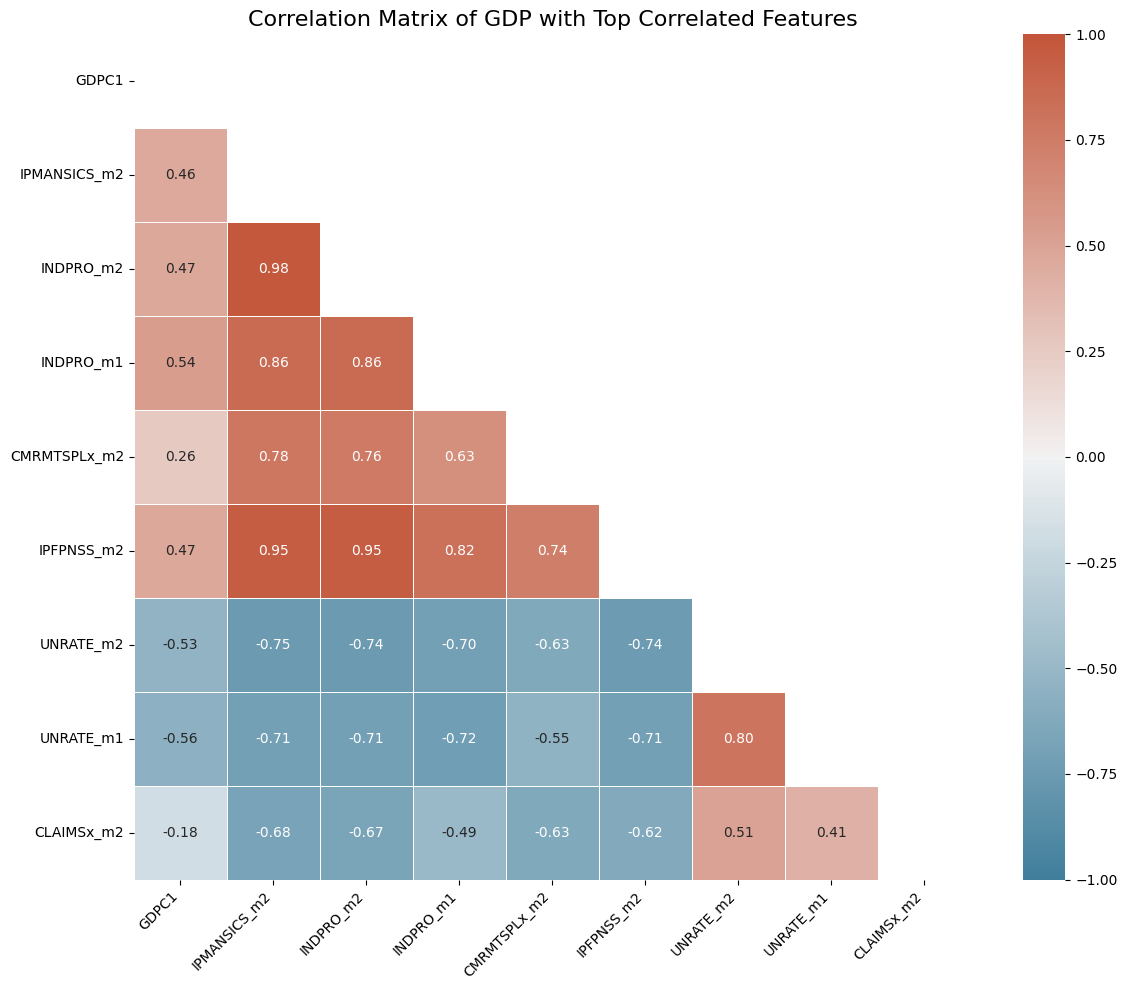

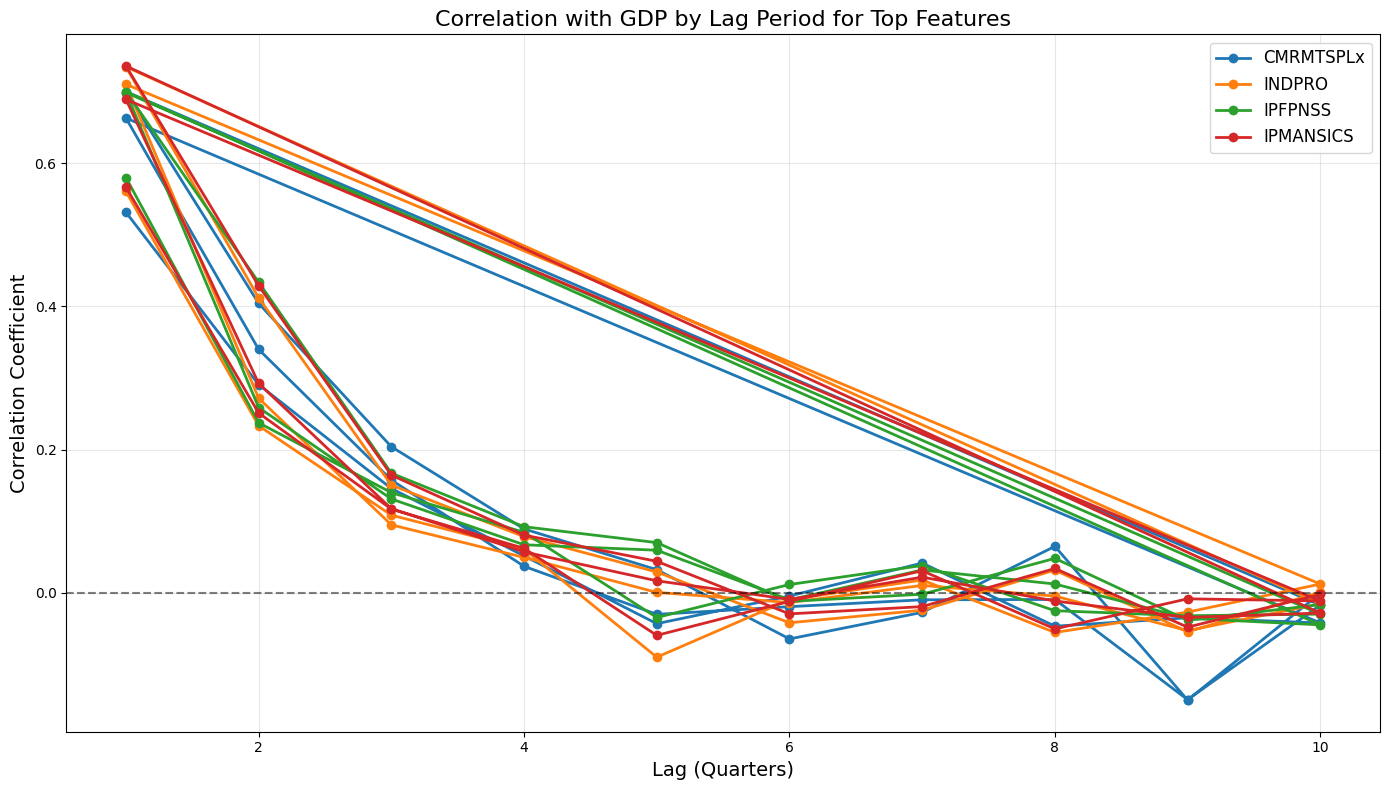

In [37]:
import pandas as pd
import numpy as np
from matplotlib.dates import YearLocator, DateFormatter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Get top features with highest absolute correlation with GDP
top_pos_features = top_correlations[top_correlations['Correlation'] > 0].head(5)['Feature'].tolist()
top_neg_features = top_correlations[top_correlations['Correlation'] < 0].head(3)['Feature'].tolist()
top_features = top_pos_features + top_neg_features

# Create a copy of the data for standardization
plot_data = all_data.copy()

# Standardize GDP and features
scaler = StandardScaler()
columns_to_scale = ['GDPC1'] + [f for f in top_features if f in all_data.columns]
plot_data[columns_to_scale] = scaler.fit_transform(plot_data[columns_to_scale])

# Create the figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Plot standardized GDP in both subplots
ax1.plot(plot_data.index, plot_data['GDPC1'], 'k-', label='Real GDP (standardized)', linewidth=2.5)
ax2.plot(plot_data.index, plot_data['GDPC1'], 'k-', label='Real GDP (standardized)', linewidth=2.5)

# Plot top features with positive correlation in the first subplot
for feature in top_pos_features:
    if feature in plot_data.columns:
        ax1.plot(plot_data.index, plot_data[feature], '--', label=f"{feature}", alpha=0.8, linewidth=1.5)

# Plot top features with negative correlation in the second subplot
for feature in top_neg_features:
    if feature in plot_data.columns:
        ax2.plot(plot_data.index, plot_data[feature], '--', label=f"{feature}", alpha=0.8, linewidth=1.5)

# Shade recession periods in both subplots
for start, end in recessions:
    ax1.axvspan(start, end, color='gray', alpha=0.2)
    ax2.axvspan(start, end, color='gray', alpha=0.2)

# Add titles and labels
ax1.set_title('GDP vs Top Positively Correlated Features (Standardized)', fontsize=14)
ax2.set_title('GDP vs Top Negatively Correlated Features (Standardized)', fontsize=14)
ax1.set_ylabel('Standardized Values', fontsize=12)
ax2.set_ylabel('Standardized Values', fontsize=12)
ax2.set_xlabel('Year', fontsize=12)

# Format x-axis to show years
ax2.xaxis.set_major_locator(YearLocator(5))
ax2.xaxis.set_major_formatter(DateFormatter('%Y'))

# Add legends
ax1.legend(loc='upper left', fontsize=10)
ax2.legend(loc='upper left', fontsize=10)

# Add grid for better readability
ax1.grid(True, alpha=0.3)
ax2.grid(True, alpha=0.3)

# Show plot
plt.tight_layout()
plt.show()

# Create a correlation heatmap for the top features
if len(top_features) > 0:
    plt.figure(figsize=(12, 10))
    corr_features = ['GDPC1'] + [f for f in top_features if f in all_data.columns]
    corr_matrix = all_data[corr_features].corr()
    
    # Create heatmap
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    cmap = sns.diverging_palette(230, 20, as_cmap=True)
    
    sns.heatmap(corr_matrix, annot=True, cmap=cmap, vmin=-1, vmax=1, 
                fmt='.2f', linewidths=0.5, mask=mask)
    plt.title('Correlation Matrix of GDP with Top Correlated Features', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Create a lag plot showing how correlation varies with different lag periods
plt.figure(figsize=(14, 8))
features_to_plot = list(set([f.split('_')[0] for f in top_features[:5]]))
lag_data = cross_corr_results[cross_corr_results['Feature'].str.contains('|'.join(features_to_plot))]

for feature_base in features_to_plot:
    # Get all variations of this feature (m0, m1, m2)
    feature_variations = lag_data[lag_data['Feature'].str.contains(feature_base)]
    if not feature_variations.empty:
        plt.plot(feature_variations['Lag'], feature_variations['Correlation'], 
                 'o-', label=feature_base, linewidth=2)

plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.title('Correlation with GDP by Lag Period for Top Features', fontsize=16)
plt.xlabel('Lag (Quarters)', fontsize=14)
plt.ylabel('Correlation Coefficient', fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


C:\Users\giada\AppData\Local\Temp\ipykernel_9324\1372182264.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lag_1_data['Suffix'] = lag_1_data['Feature'].apply(


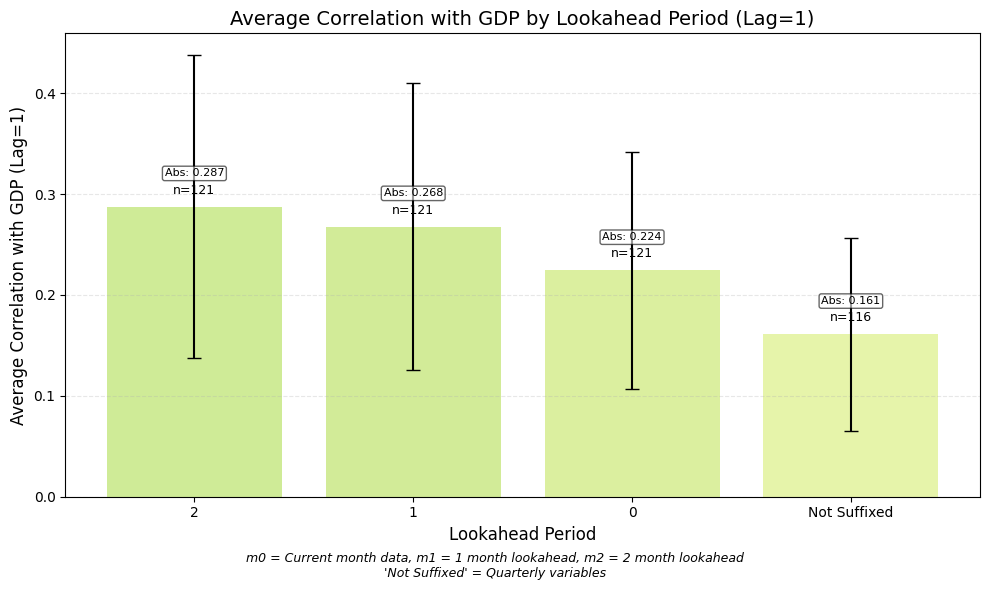

Average correlation statistics by lookahead period (Lag=1):
         Suffix  Correlation_mean  Correlation_std  Abs_Correlation_mean  \
2             2          0.206704         0.299885              0.287435   
1             1          0.192365         0.284686              0.267678   
0             0          0.160243         0.235124              0.224218   
3  Not Suffixed          0.091907         0.191762              0.160931   

   Abs_Correlation_std  Correlation_count  
2             0.222949                121  
1             0.214733                121  
0             0.174592                121  
3             0.138452                116  


In [38]:
# Calculate average cross-correlation for each suffix (m0, m1, m2) at lag 1
lag_1_data = cross_corr_results[cross_corr_results['Lag'] == 1]

# Extract the suffix from each feature name (m0, m1, m2)
lag_1_data['Suffix'] = lag_1_data['Feature'].apply(
    lambda x: 'Not Suffixed' if '_m' not in x else x.split('_m')[1]
)

# Group by suffix and calculate average correlation and count
suffix_stats = lag_1_data.groupby('Suffix').agg({
    'Correlation': ['mean', 'std', 'count'],
    'Abs_Correlation': ['mean', 'std']
}).reset_index()

# Flatten the multi-level column names
suffix_stats.columns = ['_'.join(col).strip('_') for col in suffix_stats.columns.values]

# Sort by absolute correlation values
suffix_stats = suffix_stats.sort_values('Abs_Correlation_mean', ascending=False)

# Create the barplot
plt.figure(figsize=(10, 6))
bars = plt.bar(
    suffix_stats['Suffix'],
    suffix_stats['Abs_Correlation_mean'],
    yerr=suffix_stats['Correlation_std']/2,  # Use half std dev for error bars to avoid clutter
    color=[plt.cm.RdYlGn(0.5 + 0.5 * x) for x in suffix_stats['Abs_Correlation_mean']],
    alpha=0.8,
    capsize=5
)

# Add count labels on top of bars
for i, bar in enumerate(bars):
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        bar.get_height() + (0.01 if bar.get_height() > 0 else -0.03),
        f"n={suffix_stats['Correlation_count'].iloc[i]}",
        ha='center', va='bottom', fontsize=9
    )

plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Lookahead Period', fontsize=12)
plt.ylabel('Average Correlation with GDP (Lag=1)', fontsize=12)
plt.title('Average Correlation with GDP by Lookahead Period (Lag=1)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add text explaining what m0, m1, m2 mean
plt.figtext(0.5, 0.01, 
    "m0 = Current month data, m1 = 1 month lookahead, m2 = 2 month lookahead\n'Not Suffixed' = Quarterly variables",
    ha='center', fontsize=9, style='italic')

# Add average absolute correlation values as text
for i, suffix in enumerate(suffix_stats['Suffix']):
    plt.text(
        i, 
        suffix_stats['Abs_Correlation_mean'].iloc[i] + (0.03 if suffix_stats['Abs_Correlation_mean'].iloc[i] > 0 else -0.05),
        f"Abs: {suffix_stats['Abs_Correlation_mean'].iloc[i]:.3f}",
        ha='center', fontsize=8,
        bbox=dict(facecolor='white', alpha=0.6, boxstyle='round,pad=0.2')
    )

plt.tight_layout(rect=[0, 0.04, 1, 0.98])
plt.show()

# Print the detailed statistics
print("Average correlation statistics by lookahead period (Lag=1):")
print(suffix_stats[['Suffix', 'Correlation_mean', 'Correlation_std', 
                   'Abs_Correlation_mean', 'Abs_Correlation_std', 'Correlation_count']])

C:\Users\giada\AppData\Local\Temp\ipykernel_9324\1979232798.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lag_data['Suffix'] = lag_data['Feature'].apply(
C:\Users\giada\AppData\Local\Temp\ipykernel_9324\1979232798.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lag_data['Suffix'] = lag_data['Feature'].apply(
C:\Users\giada\AppData\Local\Temp\ipykernel_9324\1979232798.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_

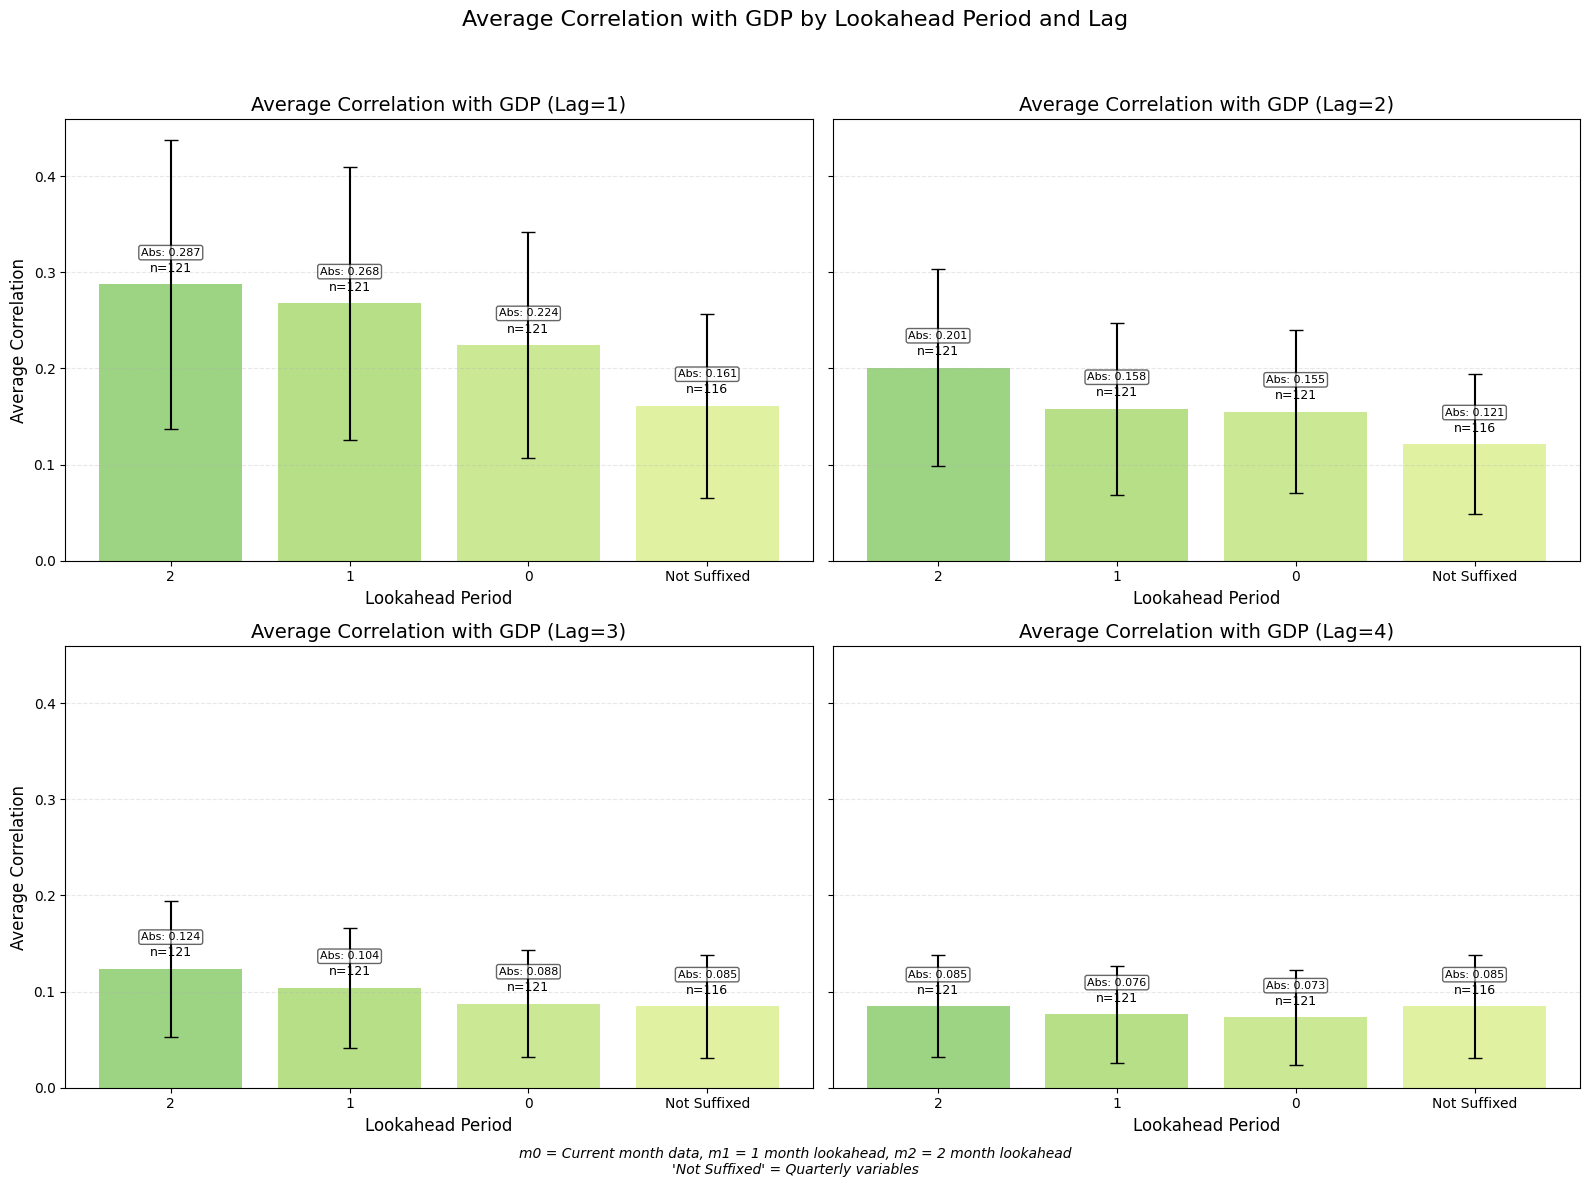


Average correlation statistics by lookahead period (Lag=1):
         Suffix  Correlation_mean  Correlation_std  Abs_Correlation_mean  \
2             2          0.206704         0.299885              0.287435   
1             1          0.192365         0.284686              0.267678   
0             0          0.160243         0.235124              0.224218   
3  Not Suffixed          0.091907         0.191762              0.160931   

   Abs_Correlation_std  Abs_Correlation_count  
2             0.222949                    121  
1             0.214733                    121  
0             0.174592                    121  
3             0.138452                    116  

Average correlation statistics by lookahead period (Lag=2):
         Suffix  Correlation_mean  Correlation_std  Abs_Correlation_mean  \
2             2          0.135902         0.204998              0.200957   
1             1          0.092505         0.179844              0.157797   
0             0          0.07

C:\Users\giada\AppData\Local\Temp\ipykernel_9324\1979232798.py:102: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lag_data['Suffix'] = lag_data['Feature'].apply(
C:\Users\giada\AppData\Local\Temp\ipykernel_9324\1979232798.py:102: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lag_data['Suffix'] = lag_data['Feature'].apply(
C:\Users\giada\AppData\Local\Temp\ipykernel_9324\1979232798.py:102: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,c

In [39]:
# Calculate average cross-correlation for each suffix (m0, m1, m2, Not Suffixed) at lags 1-4
import matplotlib.pyplot as plt
import numpy as np

# Create a 2x2 subplot figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
axes = axes.flatten()  # Flatten for easier indexing

# Define colors for consistent appearance across subplots
suffix_colors = {
    '0': plt.cm.RdYlGn(0.65),
    '1': plt.cm.RdYlGn(0.7),
    '2': plt.cm.RdYlGn(0.75),
    'Not Suffixed': plt.cm.RdYlGn(0.6)
}

# Loop through lags 1-4
for i, lag in enumerate(range(1, 5)):
    # Filter data for the current lag
    lag_data = cross_corr_results[cross_corr_results['Lag'] == lag]
    
    # Extract suffix from feature names
    lag_data['Suffix'] = lag_data['Feature'].apply(
        lambda x: 'Not Suffixed' if '_m' not in x else x.split('_m')[1]
    )
    
    # Group by suffix and calculate average correlation and other stats
    suffix_stats = lag_data.groupby('Suffix').agg({
        'Correlation': ['mean', 'std', 'count'],
        'Abs_Correlation': ['mean', 'std']
    }).reset_index()
    
    # Flatten multi-level column names
    suffix_stats.columns = ['_'.join(col).strip('_') for col in suffix_stats.columns.values]
    
    # Sort by absolute correlation values
    suffix_stats['PlotOrder'] = suffix_stats["Suffix"].apply(
        lambda x: {'0': 0, '1': 1, '2': 2, 'Not Suffixed': -1}.get(x, 4)
    )
    suffix_stats = suffix_stats.sort_values('PlotOrder', ascending=False)
    
    # Create the barplot in the corresponding subplot
    ax = axes[i]
    bars = ax.bar(
        suffix_stats['Suffix'],
        suffix_stats['Abs_Correlation_mean'],
        yerr=suffix_stats['Correlation_std']/2,  # Use half std dev for cleaner visualization
        color=[suffix_colors.get(s, plt.cm.RdYlGn(0.5)) for s in suffix_stats['Suffix']],
        alpha=0.8,
        capsize=5
    )
    
    # Add count labels on top of bars
    for j, bar in enumerate(bars):
        ax.text(
            bar.get_x() + bar.get_width()/2, 
            bar.get_height() + (0.01 if bar.get_height() > 0 else -0.03),
            f"n={suffix_stats['Correlation_count'].iloc[j]}",
            ha='center', va='bottom', fontsize=9
        )
    
    # Add absolute correlation values as text
    for j, suffix in enumerate(suffix_stats['Suffix']):
        ax.text(
            j, 
            suffix_stats['Abs_Correlation_mean'].iloc[j] + (0.03 if suffix_stats['Abs_Correlation_mean'].iloc[j] > 0 else -0.05),
            f"Abs: {suffix_stats['Abs_Correlation_mean'].iloc[j]:.3f}",
            ha='center', fontsize=8,
            bbox=dict(facecolor='white', alpha=0.6, boxstyle='round,pad=0.2')
        )
    
    # Add horizontal line at y=0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    
    # Set title and labels for each subplot
    ax.set_title(f'Average Correlation with GDP (Lag={lag})', fontsize=14)
    ax.set_xlabel('Lookahead Period', fontsize=12)
    
    # Only add y-label on the left subplots
    if i % 2 == 0:
        ax.set_ylabel('Average Correlation', fontsize=12)
    
    # Add grid for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.3)

# Add a common title for the entire figure
fig.suptitle('Average Correlation with GDP by Lookahead Period and Lag', fontsize=16)

# Add an explanation of what m0, m1, m2 mean at the bottom of the figure
fig.text(0.5, 0.01, 
    "m0 = Current month data, m1 = 1 month lookahead, m2 = 2 month lookahead\n'Not Suffixed' = Quarterly variables",
    ha='center', fontsize=10, style='italic')

# Adjust spacing between subplots and make room for the annotations
fig.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

# Print summary statistics for each lag
for lag in range(1, 5):
    lag_data = cross_corr_results[cross_corr_results['Lag'] == lag]
    lag_data['Suffix'] = lag_data['Feature'].apply(
        lambda x: 'Not Suffixed' if '_m' not in x else x.split('_m')[1]
    )
    
    suffix_stats = lag_data.groupby('Suffix').agg({
        'Correlation': ['mean', 'std'],
        'Abs_Correlation': ['mean', 'std', 'count']
    }).reset_index()
    
    # Flatten multi-level column names
    suffix_stats.columns = ['_'.join(col).strip('_') for col in suffix_stats.columns.values]
    suffix_stats = suffix_stats.sort_values('Abs_Correlation_mean', ascending=False)
    
    print(f"\nAverage correlation statistics by lookahead period (Lag={lag}):")
    print(suffix_stats[['Suffix', 'Correlation_mean', 'Correlation_std', 
                       'Abs_Correlation_mean', 'Abs_Correlation_std', 'Abs_Correlation_count']])


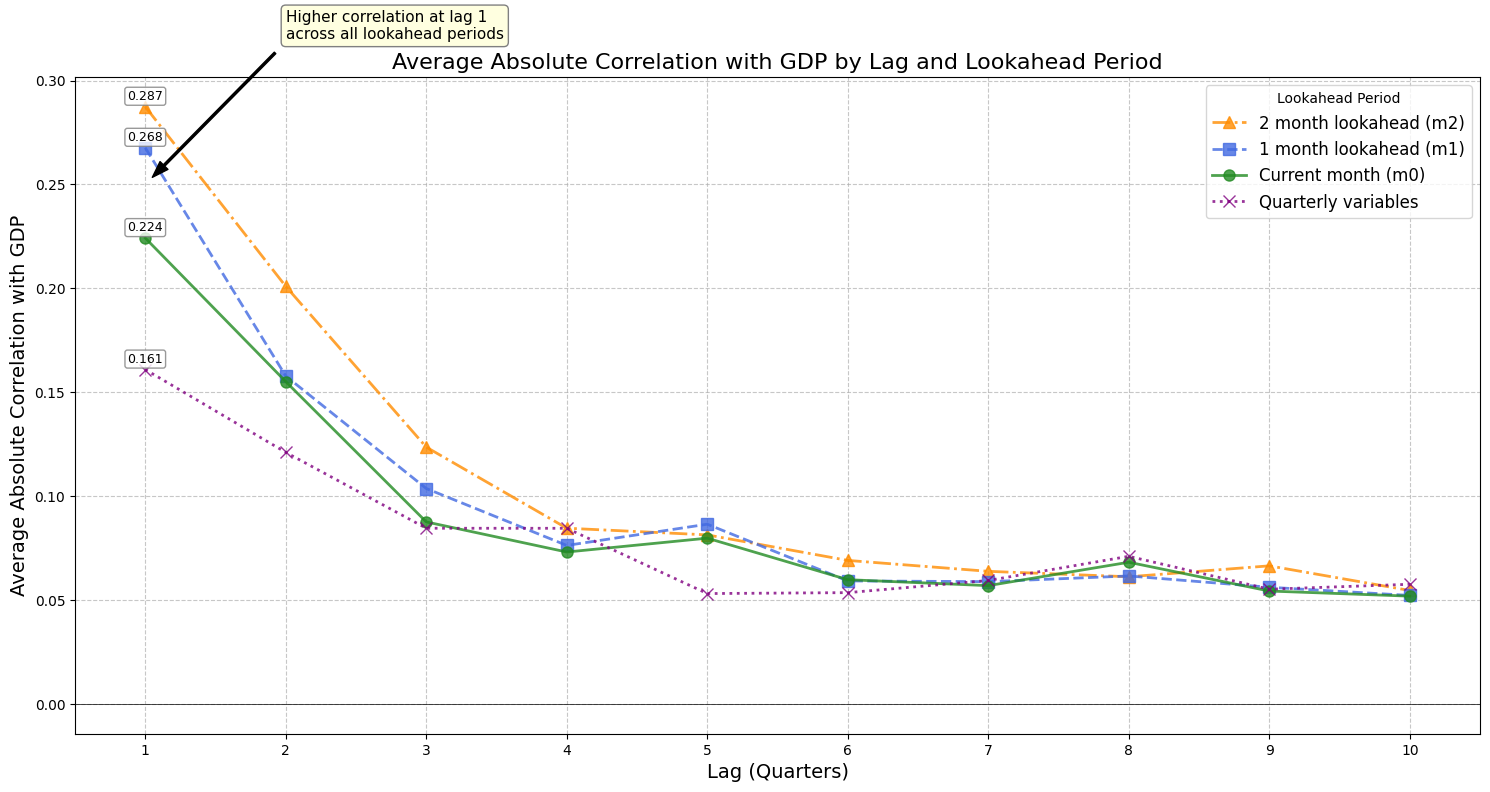

Average absolute correlation statistics by lag and lookahead period:
Lag_             1      2      3      4      5      6      7      8      9   \
Suffix_                                                                       
0             0.224  0.155  0.088  0.073  0.080  0.060  0.057  0.068  0.054   
1             0.268  0.158  0.104  0.076  0.086  0.059  0.059  0.062  0.056   
2             0.287  0.201  0.124  0.085  0.081  0.069  0.064  0.061  0.066   
Not Suffixed  0.161  0.121  0.085  0.085  0.053  0.054  0.059  0.071  0.055   

Lag_             10  
Suffix_              
0             0.052  
1             0.052  
2             0.055  
Not Suffixed  0.058  


In [41]:
# Create a combined graph with lags on x-axis and correlation on y-axis
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Extract suffix from feature names and add as column
if 'Suffix' not in cross_corr_results.columns:
    cross_corr_results['Suffix'] = cross_corr_results['Feature'].apply(
        lambda x: 'Not Suffixed' if '_m' not in x else x.split('_m')[1]
    )

# Group by lag and suffix to calculate mean correlation and other stats
lag_suffix_stats = cross_corr_results.groupby(['Lag', 'Suffix']).agg({
    'Correlation': ['mean', 'std', 'count'],
    'Abs_Correlation': ['mean', 'std']
}).reset_index()

# Flatten multi-level column names
lag_suffix_stats.columns = ['_'.join(col).strip('_') for col in lag_suffix_stats.columns.values]

# Fix column names - ensure Suffix and Lag columns are named correctly
if 'Suffix_' not in lag_suffix_stats.columns and 'Suffix' in lag_suffix_stats.columns:
    lag_suffix_stats = lag_suffix_stats.rename(columns={'Suffix': 'Suffix_'})
if 'Lag_' not in lag_suffix_stats.columns and 'Lag' in lag_suffix_stats.columns:
    lag_suffix_stats = lag_suffix_stats.rename(columns={'Lag': 'Lag_'})

# Create a figure for the combined lag plot
plt.figure(figsize=(15, 8))

# Define colors and markers for each suffix
suffix_styles = {
    '0': {'color': 'forestgreen', 'marker': 'o', 'linestyle': '-', 'label': 'Current month (m0)'},
    '1': {'color': 'royalblue', 'marker': 's', 'linestyle': '--', 'label': '1 month lookahead (m1)'},
    '2': {'color': 'darkorange', 'marker': '^', 'linestyle': '-.', 'label': '2 month lookahead (m2)'},
    'Not Suffixed': {'color': 'purple', 'marker': 'x', 'linestyle': ':', 'label': 'Quarterly variables'}
}

# Sort suffixes for consistent order in the legend
suffixes = ['2', '1', '0', 'Not Suffixed']

# Plot each suffix as a separate line
for suffix in suffixes:
    suffix_data = lag_suffix_stats[lag_suffix_stats['Suffix_'] == suffix]
    if not suffix_data.empty:
        plt.plot(
            suffix_data['Lag_'],
            suffix_data['Abs_Correlation_mean'],
            **suffix_styles[suffix],
            linewidth=2,
            markersize=8,
            alpha=0.8
        )

# Add grid and labels
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlabel('Lag (Quarters)', fontsize=14)
plt.ylabel('Average Absolute Correlation with GDP', fontsize=14)
plt.title('Average Absolute Correlation with GDP by Lag and Lookahead Period', fontsize=16)
plt.xticks(range(1, 11))  # Updated to show 10 lags
plt.xlim(0.5, 10.5)       # Updated x-axis limit for 10 lags

# Add legend with better positioning
plt.legend(title='Lookahead Period', loc='upper right', fontsize=12)

# Add text annotations for the highest values
for suffix in suffixes:
    suffix_data = lag_suffix_stats[lag_suffix_stats['Suffix_'] == suffix]
    if not suffix_data.empty:
        max_idx = suffix_data['Abs_Correlation_mean'].idxmax()
        max_lag = suffix_data.loc[max_idx, 'Lag_']
        max_corr = suffix_data.loc[max_idx, 'Abs_Correlation_mean']
        
        if max_corr > 0.15:  # Only annotate higher correlation values
            plt.annotate(
                f"{max_corr:.3f}",
                xy=(max_lag, max_corr),
                xytext=(0, 5),
                textcoords='offset points',
                ha='center',
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8)
            )

# Highlight the most important observations
plt.annotate(
    "Higher correlation at lag 1 \nacross all lookahead periods",
    xy=(1, 0.25),
    xytext=(2, 0.32),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray")
)

# Add horizontal line at y=0
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Show the plot with tight layout
plt.tight_layout()
plt.show()

# Print the data summary for reference
print("Average absolute correlation statistics by lag and lookahead period:")
print(lag_suffix_stats.pivot_table(
    index='Suffix_', 
    columns='Lag_', 
    values='Abs_Correlation_mean'
).round(3))


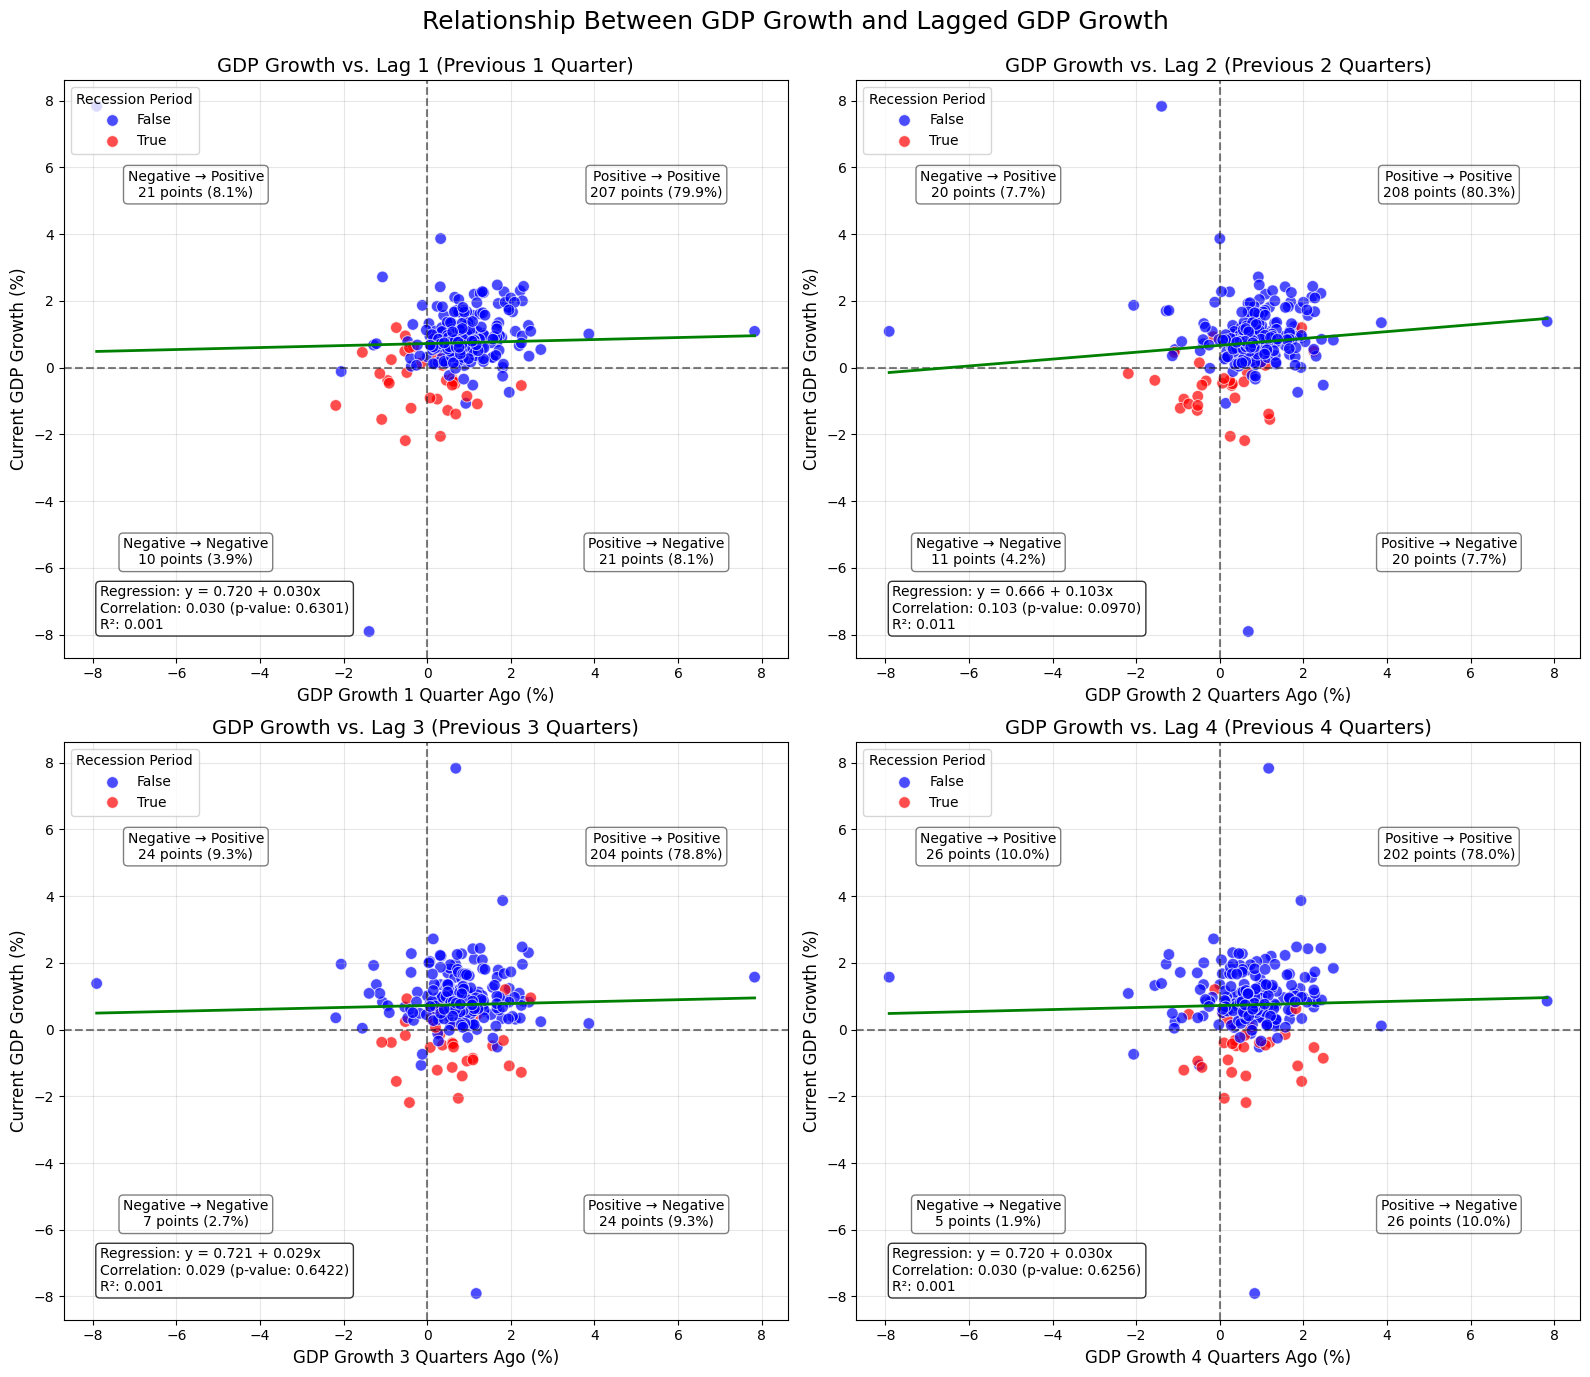

Summary Statistics for GDP Growth Lag Relationships:

Lag 1:
Correlation: 0.030 (p-value: 0.6301)
Persistence (maintaining same sign): 79.9%
Probability of positive growth after positive growth: 88.6%
Probability of positive growth after negative growth: 83.9%

Lag 2:
Correlation: 0.103 (p-value: 0.0970)
Persistence (maintaining same sign): 79.9%
Probability of positive growth after positive growth: 88.6%
Probability of positive growth after negative growth: 83.9%

Lag 3:
Correlation: 0.029 (p-value: 0.6422)
Persistence (maintaining same sign): 79.9%
Probability of positive growth after positive growth: 88.6%
Probability of positive growth after negative growth: 83.9%

Lag 4:
Correlation: 0.030 (p-value: 0.6256)
Persistence (maintaining same sign): 79.9%
Probability of positive growth after positive growth: 88.6%
Probability of positive growth after negative growth: 83.9%


In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy import stats

import matplotlib.pyplot as plt

# Create a figure with 4 subplots for different lags
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

# Prepare the data
gdp_lags = gdp_series[['GDP_Change']].copy()
gdp_lags['GDP_Change_Pct'] = gdp_lags['GDP_Change'] * 100  # Convert to percentage

# Create lagged variables
for lag in range(1, 5):
    gdp_lags[f'Lag_{lag}'] = gdp_lags['GDP_Change_Pct'].shift(lag)

# Drop rows with NaN values
gdp_lags = gdp_lags.dropna()

# Define colors for recession vs non-recession points
gdp_lags['In_Recession'] = False
for start, end in recessions:
    mask = (gdp_lags.index >= start) & (gdp_lags.index <= end)
    gdp_lags.loc[mask, 'In_Recession'] = True

# Create scatterplots for each lag
for i, lag in enumerate(range(1, 5)):
    ax = axes[i]
    
    # Create the scatterplot
    sns.scatterplot(
        x=f'Lag_{lag}',
        y='GDP_Change_Pct',
        hue='In_Recession',
        palette={True: 'red', False: 'blue'},
        alpha=0.7,
        s=70,
        data=gdp_lags,
        ax=ax
    )
    
    # Add reference lines at x=0 and y=0
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax.axvline(x=0, color='black', linestyle='--', alpha=0.5)
    
    # Fit a linear regression model
    X = gdp_lags[f'Lag_{lag}'].values.reshape(-1, 1)
    y = gdp_lags['GDP_Change_Pct'].values
    model = LinearRegression()
    model.fit(X, y)
    
    # Calculate correlation and p-value
    corr, p_value = stats.pearsonr(gdp_lags[f'Lag_{lag}'], gdp_lags['GDP_Change_Pct'])
    
    # Add regression line
    x_range = np.linspace(gdp_lags[f'Lag_{lag}'].min(), gdp_lags[f'Lag_{lag}'].max(), 100)
    y_pred = model.predict(x_range.reshape(-1, 1))
    ax.plot(x_range, y_pred, color='green', linewidth=2)
    
    # Calculate statistics for points in different quadrants
    q1 = gdp_lags[(gdp_lags[f'Lag_{lag}'] > 0) & (gdp_lags['GDP_Change_Pct'] > 0)]  # Positive → Positive
    q2 = gdp_lags[(gdp_lags[f'Lag_{lag}'] < 0) & (gdp_lags['GDP_Change_Pct'] > 0)]  # Negative → Positive
    q3 = gdp_lags[(gdp_lags[f'Lag_{lag}'] < 0) & (gdp_lags['GDP_Change_Pct'] < 0)]  # Negative → Negative
    q4 = gdp_lags[(gdp_lags[f'Lag_{lag}'] > 0) & (gdp_lags['GDP_Change_Pct'] < 0)]  # Positive → Negative
    
    # Calculate counts and percentages
    total = len(gdp_lags)
    q1_pct = len(q1) / total * 100
    q2_pct = len(q2) / total * 100
    q3_pct = len(q3) / total * 100
    q4_pct = len(q4) / total * 100
    
    # Create label for each quadrant
    q1_label = f"Positive → Positive\n{len(q1)} points ({q1_pct:.1f}%)"
    q2_label = f"Negative → Positive\n{len(q2)} points ({q2_pct:.1f}%)"
    q3_label = f"Negative → Negative\n{len(q3)} points ({q3_pct:.1f}%)"
    q4_label = f"Positive → Negative\n{len(q4)} points ({q4_pct:.1f}%)"
    
    # Add labels to each quadrant
    ax.text(gdp_lags[f'Lag_{lag}'].max() * 0.7, gdp_lags['GDP_Change_Pct'].max() * 0.7, q1_label, 
           ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5, boxstyle='round'))
    ax.text(gdp_lags[f'Lag_{lag}'].min() * 0.7, gdp_lags['GDP_Change_Pct'].max() * 0.7, q2_label, 
           ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5, boxstyle='round'))
    ax.text(gdp_lags[f'Lag_{lag}'].min() * 0.7, gdp_lags['GDP_Change_Pct'].min() * 0.7, q3_label, 
           ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5, boxstyle='round'))
    ax.text(gdp_lags[f'Lag_{lag}'].max() * 0.7, gdp_lags['GDP_Change_Pct'].min() * 0.7, q4_label, 
           ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5, boxstyle='round'))
    
    # Add regression info text
    reg_text = f"Regression: y = {model.intercept_:.3f} + {model.coef_[0]:.3f}x\n"
    reg_text += f"Correlation: {corr:.3f} (p-value: {p_value:.4f})\n"
    reg_text += f"R²: {model.score(X, y):.3f}"
    
    ax.text(0.05, 0.05, reg_text, transform=ax.transAxes, 
           bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'),
           fontsize=10)
    
    # Set titles and labels
    ax.set_title(f'GDP Growth vs. Lag {lag} (Previous {lag} Quarter{"s" if lag > 1 else ""})', fontsize=14)
    ax.set_xlabel(f'GDP Growth {lag} Quarter{"s" if lag > 1 else ""} Ago (%)', fontsize=12)
    ax.set_ylabel('Current GDP Growth (%)', fontsize=12)
    
    # Add legend
    ax.legend(title='Recession Period', loc='upper left')
    
    # Add grid
    ax.grid(True, alpha=0.3)

# Add a common title
plt.suptitle('Relationship Between GDP Growth and Lagged GDP Growth', fontsize=18, y=0.98)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.93)

# Show the plot
plt.show()

# Print summary statistics for the lagged relationships
print("Summary Statistics for GDP Growth Lag Relationships:")
for lag in range(1, 5):
    corr, p_value = stats.pearsonr(gdp_lags[f'Lag_{lag}'], gdp_lags['GDP_Change_Pct'])
    print(f"\nLag {lag}:")
    print(f"Correlation: {corr:.3f} (p-value: {p_value:.4f})")
    
    # Calculate persistence (probability of maintaining same sign)
    persistence = (len(q1) + len(q3)) / total * 100
    print(f"Persistence (maintaining same sign): {persistence:.1f}%")
    
    # Calculate transition probabilities
    pos_to_pos = len(q1) / (len(q1) + len(q4)) * 100
    neg_to_pos = len(q2) / (len(q2) + len(q3)) * 100
    print(f"Probability of positive growth after positive growth: {pos_to_pos:.1f}%")
    print(f"Probability of positive growth after negative growth: {neg_to_pos:.1f}%")

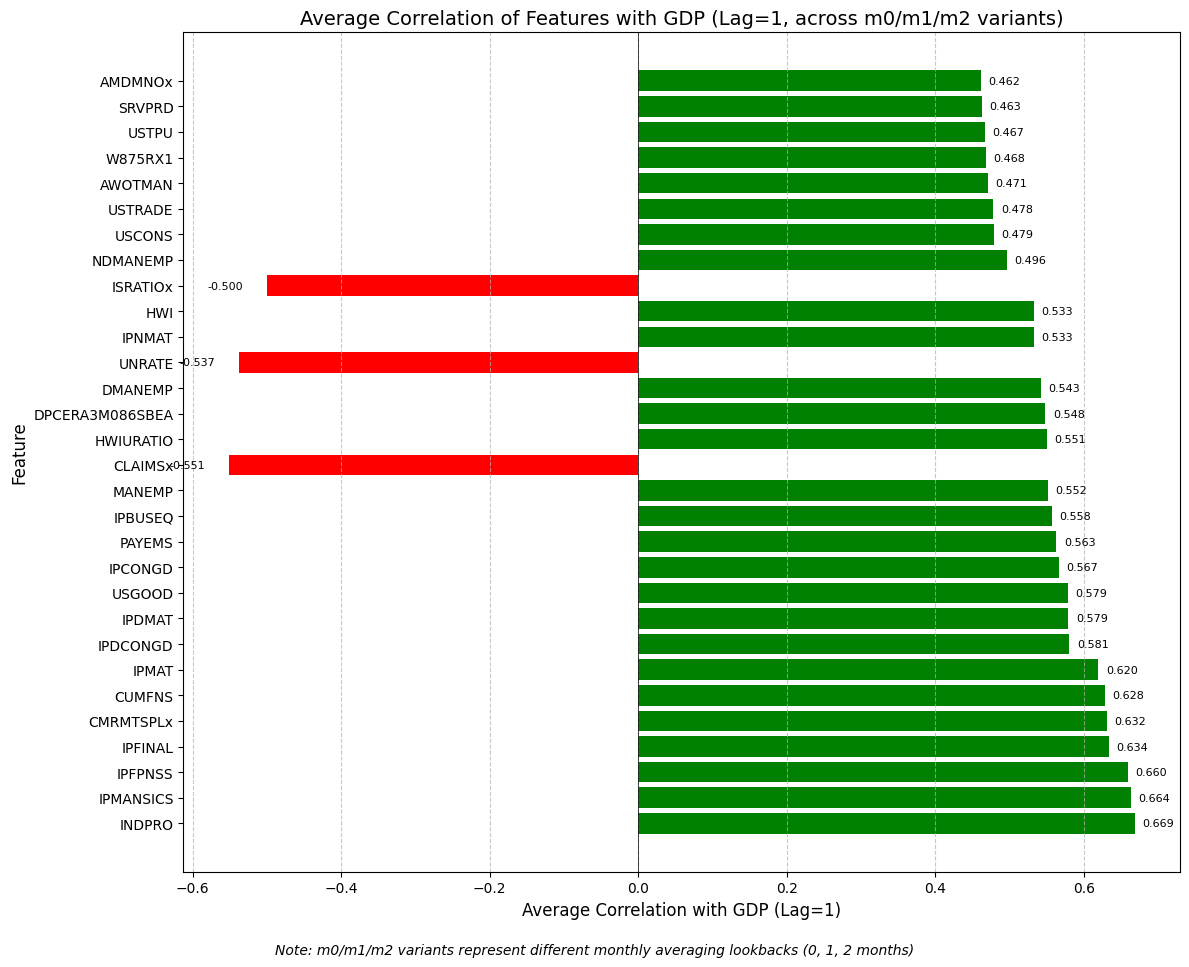

Top 10 features with highest average absolute correlation with GDP (Lag=1):
    Base_Feature  Correlation  Abs_Correlation  Feature
111       INDPRO     0.668564         0.668564        3
124    IPMANSICS     0.663867         0.663867        3
122      IPFPNSS     0.659574         0.659574        3
121      IPFINAL     0.633983         0.633983        3
32     CMRMTSPLx     0.631562         0.631562        3
46        CUMFNS     0.628405         0.628405        3
125        IPMAT     0.619750         0.619750        3
119     IPDCONGD     0.580643         0.580643        3
120       IPDMAT     0.579241         0.579241        3
218       USGOOD     0.578516         0.578516        3


In [23]:
import pandas as pd
import numpy as np
import seaborn as sns

# Calculate the average correlation for each base feature (across m0, m1, m2 variants)
import matplotlib.pyplot as plt

# Extract base feature names (removing _m0, _m1, _m2 suffixes)
cross_corr_results['Base_Feature'] = cross_corr_results['Feature'].apply(
    lambda x: x.split('_m')[0] if '_m' in x else x
)

# Filter for lag 1 correlations (as these are strongest based on previous analysis)
lag_1_corr = cross_corr_results[cross_corr_results['Lag'] == 1]

# Group by base feature and calculate mean correlation
avg_correlations = lag_1_corr.groupby('Base_Feature').agg({
    'Correlation': 'mean',
    'Abs_Correlation': 'mean',
    'Feature': 'count'  # Count how many variants (m0, m1, m2) exist
}).reset_index()

# Sort by absolute correlation
avg_correlations = avg_correlations.sort_values('Abs_Correlation', ascending=False)

# Filter to show only features that have at least 2 variants
avg_correlations = avg_correlations[avg_correlations['Feature'] >= 2].head(30)

# Create a horizontal bar plot
plt.figure(figsize=(12, 10))
bars = plt.barh(
    y=avg_correlations['Base_Feature'],
    width=avg_correlations['Correlation'],
    color=avg_correlations['Correlation'].apply(lambda x: 'green' if x > 0 else 'red')
)

# Add value labels to the bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    label_x_pos = width + 0.01 if width > 0 else width - 0.08
    plt.text(label_x_pos, bar.get_y() + bar.get_height()/2, 
             f'{avg_correlations["Correlation"].iloc[i]:.3f}',
             va='center', color='black', fontsize=8)

plt.xlabel('Average Correlation with GDP (Lag=1)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Average Correlation of Features with GDP (Lag=1, across m0/m1/m2 variants)', fontsize=14)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add a text note about what m0, m1, m2 represent
plt.figtext(0.5, 0.01, 
           "Note: m0/m1/m2 variants represent different monthly averaging lookbacks (0, 1, 2 months)",
           ha='center', fontsize=10, style='italic')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])  # Adjust layout to make room for the note
plt.show()

# Print top 10 average correlations (both positive and negative)
print("Top 10 features with highest average absolute correlation with GDP (Lag=1):")
print(avg_correlations[['Base_Feature', 'Correlation', 'Abs_Correlation', 'Feature']].head(10))

In [24]:
# Create a list of the features you want to check
features_to_check = [
    'PCESVx',
    'PRFIx',
    'A014RE1Q156NBEA',
    'DPCERA3M086SBEA',
    'CMRMTSPLx',
    'INDPRO',
    'IPMAT',
    'IPMANSICS',
    'IPB51222S',
    'CUMFNS',
    'HWIURATIO',
    'CLAIMSx',
    'PAYEMS',
    'USGOOD'
]

# Check if these features appear in the top 100 cross-correlated features
# We need to check for both the original feature names and versions with _m0, _m1, _m2 suffixes
found_features = []
not_found_features = []

for feature in features_to_check:
    # Create variations with month suffixes
    feature_variations = [
        feature,
        f"{feature}_m0",
        f"{feature}_m1", 
        f"{feature}_m2"
    ]
    
    # Check if any variation is in the top correlations
    found = False
    for var in feature_variations:
        if any(var == f for f in top_correlations['Feature']):
            matches = top_correlations[top_correlations['Feature'] == var]
            found_features.append({
                'Feature': feature,
                'Variation': var,
                'Lag': matches['Lag'].values[0],
                'Correlation': matches['Correlation'].values[0]
            })
            found = True
            break
    
    if not found:
        not_found_features.append(feature)

# Create a DataFrame with the results
found_df = pd.DataFrame(found_features)
if not found_df.empty:
    # Sort by absolute correlation value
    found_df['Abs_Correlation'] = found_df['Correlation'].abs()
    found_df = found_df.sort_values('Abs_Correlation', ascending=False)

# Print the results
print(f"Found {len(found_features)} out of {len(features_to_check)} features in the top 100 cross-correlations:")
if not found_df.empty:
    print(found_df[['Feature', 'Variation', 'Lag', 'Correlation']])
print("\nFeatures not found in top 100:")
print(not_found_features)

Found 11 out of 14 features in the top 100 cross-correlations:
            Feature           Variation  Lag  Correlation
4             IPMAT            IPMAT_m1    1     0.666436
10           USGOOD           USGOOD_m1    1     0.606684
1   DPCERA3M086SBEA  DPCERA3M086SBEA_m1    1     0.588507
7         HWIURATIO        HWIURATIO_m1    1     0.584029
9            PAYEMS           PAYEMS_m1    1     0.583278
5         IPMANSICS        IPMANSICS_m0    1     0.566523
8           CLAIMSx          CLAIMSx_m1    1    -0.565497
3            INDPRO           INDPRO_m0    1     0.560602
2         CMRMTSPLx        CMRMTSPLx_m0    1     0.531451
6            CUMFNS           CUMFNS_m0    1     0.530787
0             PRFIx               PRFIx    1     0.523866

Features not found in top 100:
['PCESVx', 'A014RE1Q156NBEA', 'IPB51222S']


C:\Users\giada\AppData\Local\Temp\ipykernel_9324\464068199.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Decade', y='GDP_Change_Pct', data=gdp_no_covid,


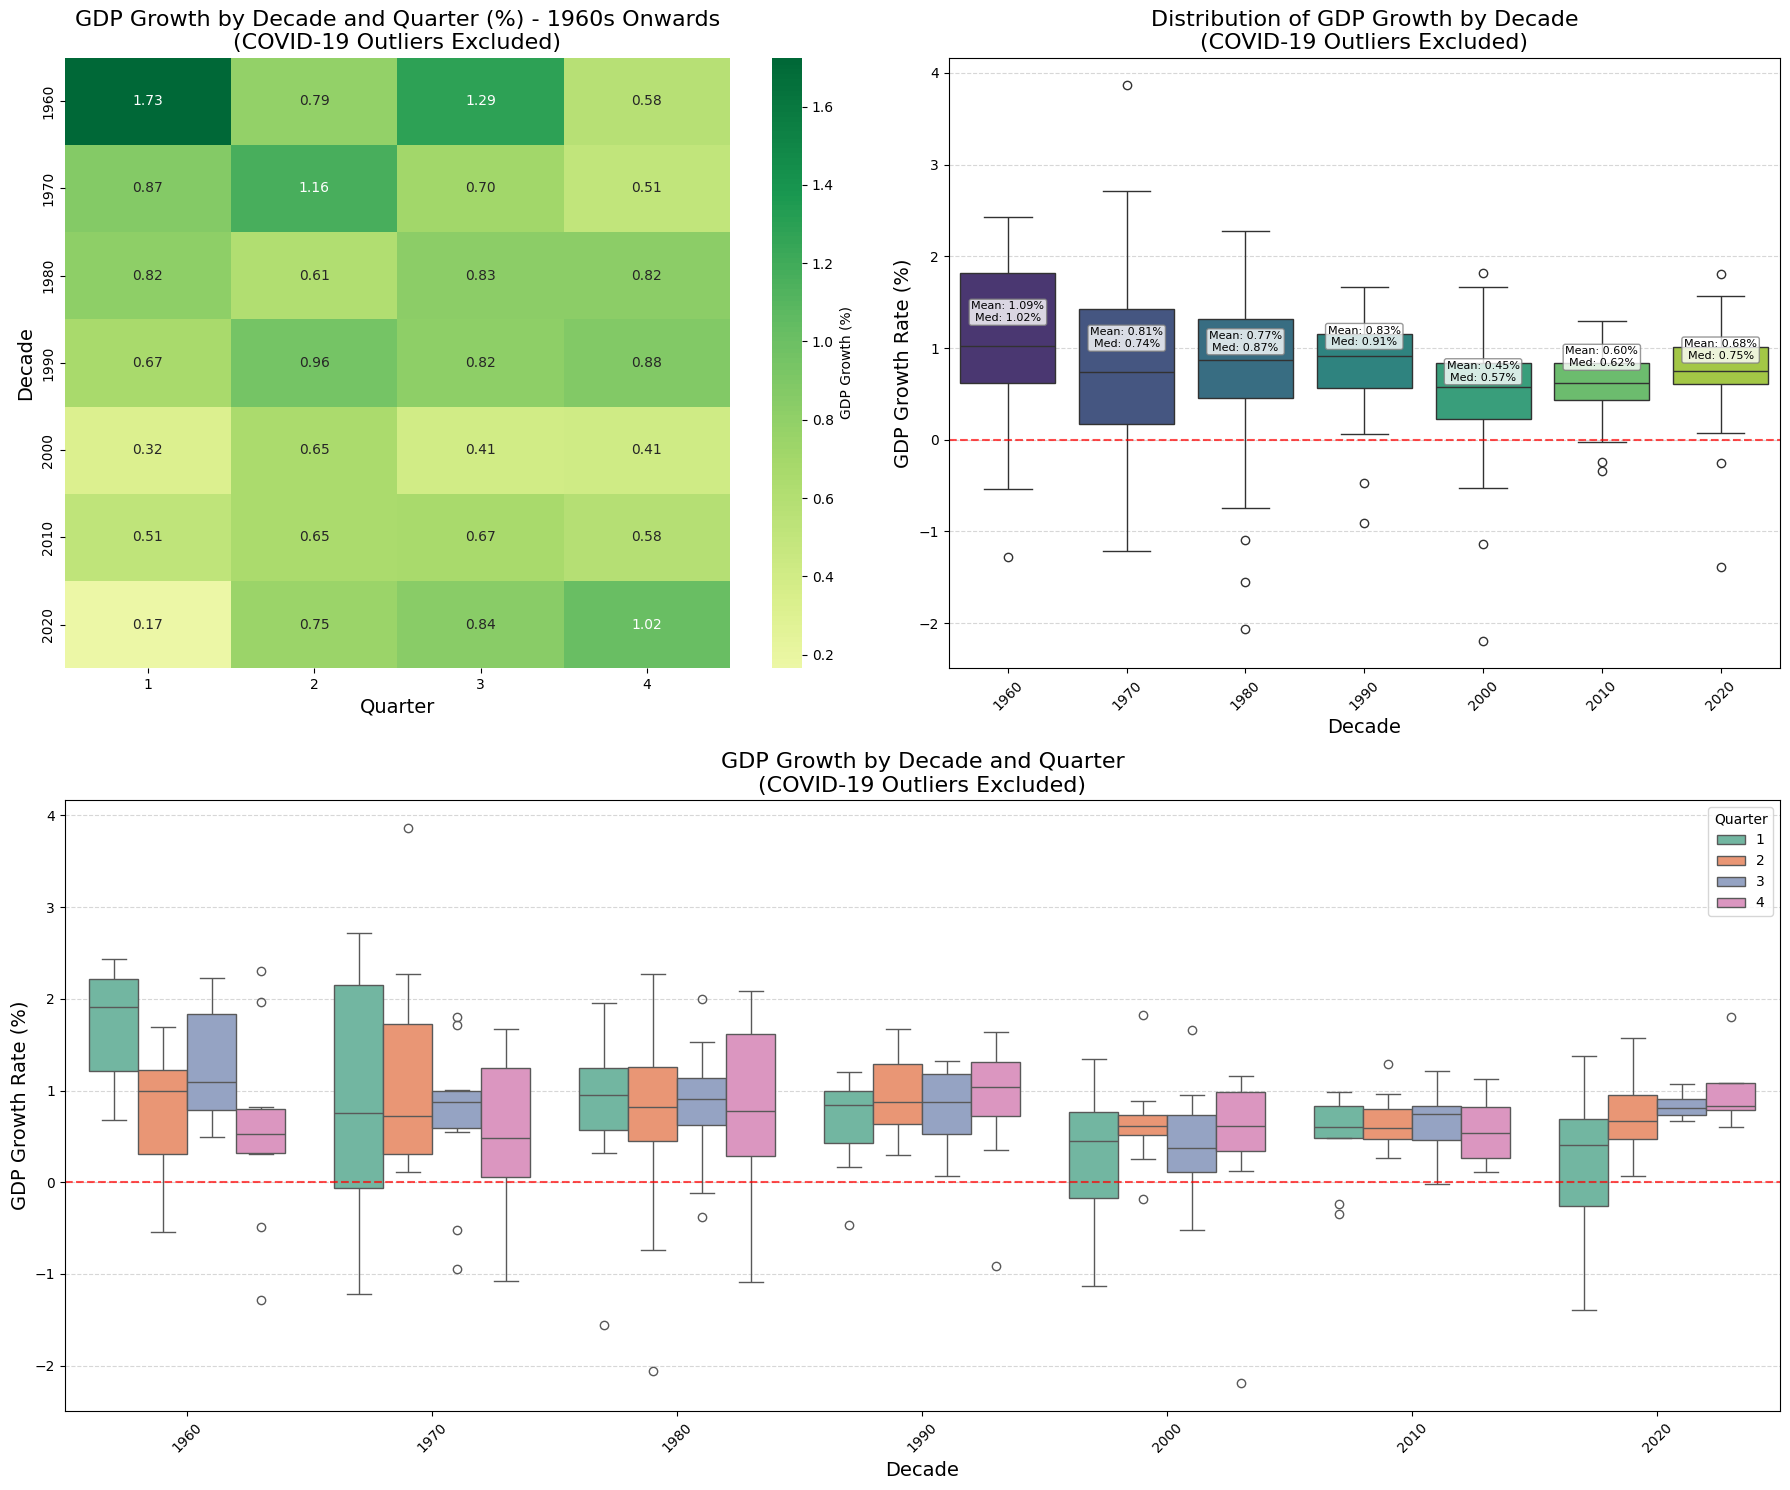

C:\Users\giada\AppData\Local\Temp\ipykernel_9324\464068199.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(
C:\Users\giada\AppData\Local\Temp\ipykernel_9324\464068199.py:124: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
C:\Users\giada\AppData\Local\Temp\ipykernel_9324\464068199.py:124: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
C:\Users\giada\AppData\Local\Temp\ipykernel_9324\464068199.py:124: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
C:\Use

<Figure size 1800x1500 with 0 Axes>

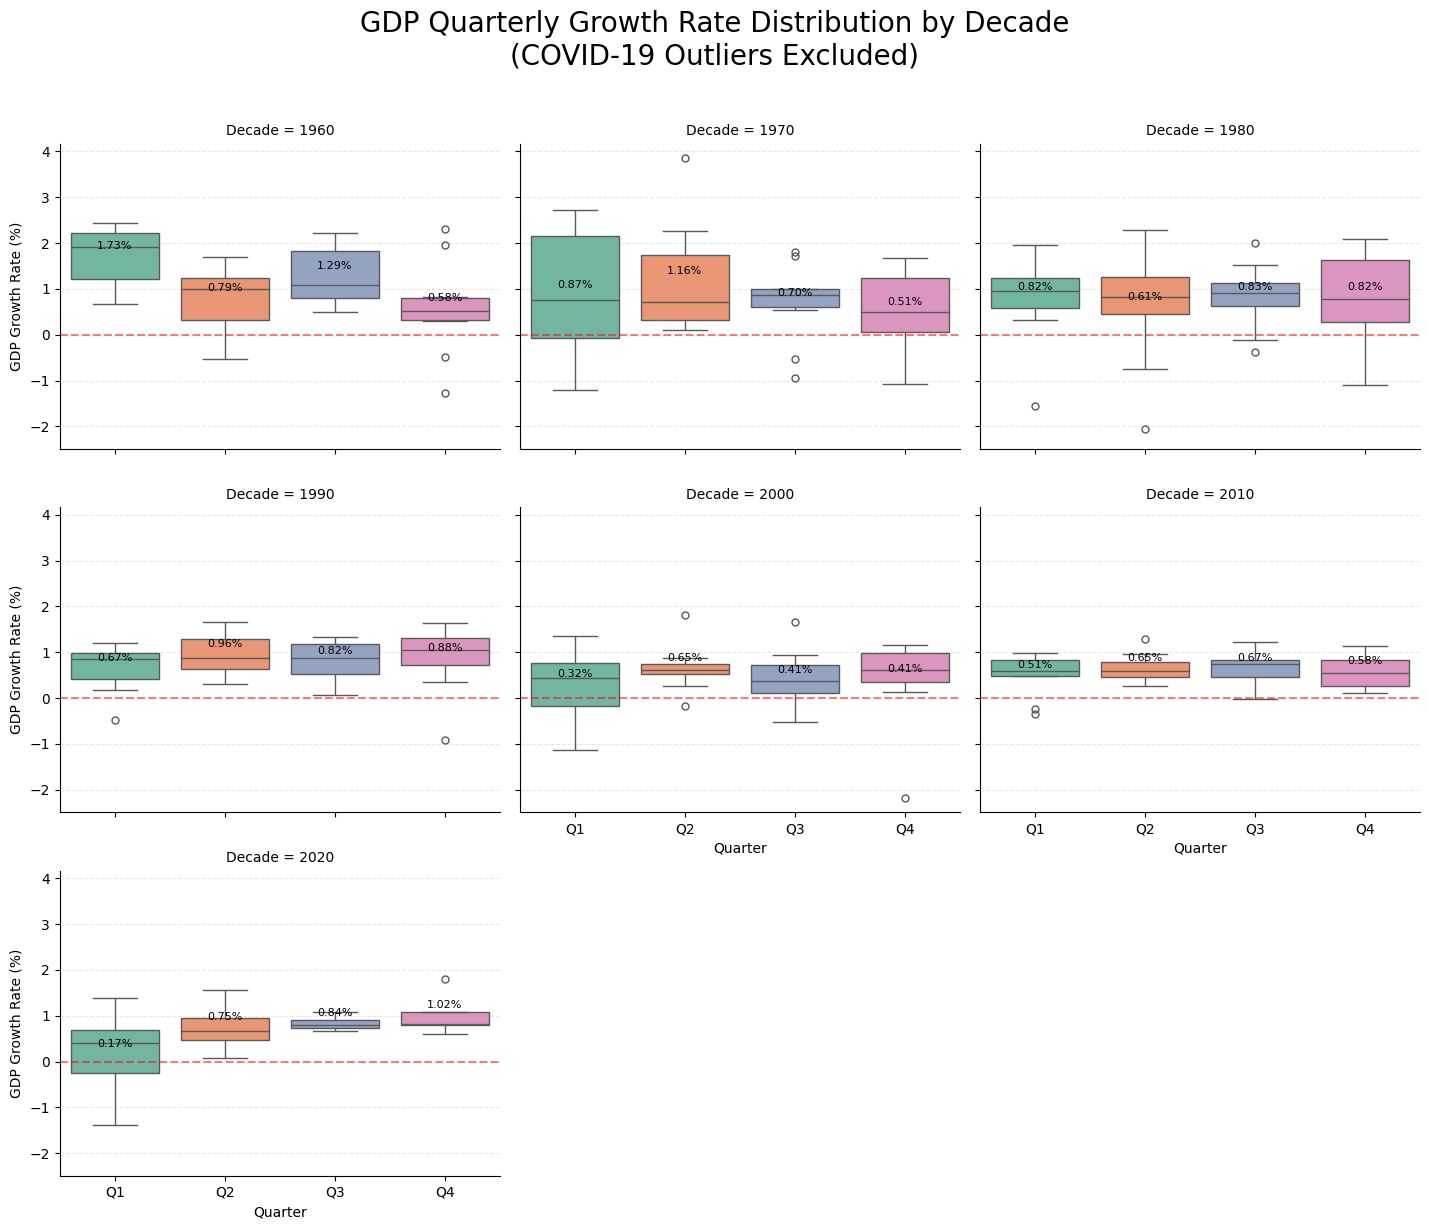

GDP Growth Statistics by Decade and Quarter (1960s onwards, COVID-19 outliers excluded):
 Decade  Quarter  mean  median  std   min  max  Negative Growth (%)
   1960        1  1.73    1.91 0.64  0.68 2.43                 0.00
   1960        2  0.79    1.00 0.73 -0.54 1.70                10.00
   1960        3  1.29    1.09 0.65  0.49 2.22                 0.00
   1960        4  0.58    0.52 1.04 -1.28 2.30                20.00
   1970        1  0.87    0.75 1.42 -1.22 2.72                30.00
   1970        2  1.16    0.72 1.20  0.11 3.86                 0.00
   1970        3  0.70    0.87 0.86 -0.95 1.80                20.00
   1970        4  0.51    0.49 0.86 -1.07 1.67                20.00
   1980        1  0.82    0.95 0.99 -1.55 1.96                10.00
   1980        2  0.61    0.82 1.24 -2.06 2.28                20.00
   1980        3  0.83    0.91 0.70 -0.38 2.00                20.00
   1980        4  0.82    0.78 0.97 -1.09 2.09                10.00
   1990        1  0.67    0

In [25]:
# GDP growth analysis by decade and quarter - excluding 1950s with boxplots
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for decade analysis
gdp_decade_analysis = gdp_series[['GDPC1', 'GDP_Change']].copy()
gdp_decade_analysis = gdp_decade_analysis.reset_index()
gdp_decade_analysis['Year'] = gdp_decade_analysis['sasdate'].dt.year
gdp_decade_analysis['Quarter'] = gdp_decade_analysis['sasdate'].dt.quarter
gdp_decade_analysis['Decade'] = (gdp_decade_analysis['Year'] // 10) * 10

# Filter out the 1950s (any data from years before 1960)
gdp_decade_filtered = gdp_decade_analysis[gdp_decade_analysis['Year'] >= 1960].copy()

# Convert the GDP change to percentage for better readability
gdp_decade_filtered['GDP_Change_Pct'] = gdp_decade_filtered['GDP_Change'] * 100

# Identify COVID-19 outliers (Q2 2020 and Q3 2020)
covid_outlier_mask = ((gdp_decade_filtered['Year'] == 2020) & 
                     ((gdp_decade_filtered['Quarter'] == 2) | 
                      (gdp_decade_filtered['Quarter'] == 3)))

# Create a non-covid dataset for statistical calculations
gdp_no_covid = gdp_decade_filtered[~covid_outlier_mask].copy()

# Create a figure with multiple visualizations
plt.figure(figsize=(18, 15))

# 1. Heatmap of GDP growth by decade and quarter (excluding 1950s)
plt.subplot(2, 2, 1)
decade_quarter_heatmap = gdp_no_covid.pivot_table(
    values='GDP_Change_Pct', 
    index='Decade', 
    columns='Quarter', 
    aggfunc='mean'
)

sns.heatmap(decade_quarter_heatmap, annot=True, cmap='RdYlGn', center=0, 
            fmt='.2f', cbar_kws={'label': 'GDP Growth (%)'})
plt.title('GDP Growth by Decade and Quarter (%) - 1960s Onwards\n(COVID-19 Outliers Excluded)', fontsize=16)
plt.xlabel('Quarter', fontsize=14)
plt.ylabel('Decade', fontsize=14)

# 2. Boxplot showing distribution by decade
plt.subplot(2, 2, 2)
sns.boxplot(x='Decade', y='GDP_Change_Pct', data=gdp_no_covid, 
            palette='viridis')
plt.title('Distribution of GDP Growth by Decade\n(COVID-19 Outliers Excluded)', fontsize=16)
plt.xlabel('Decade', fontsize=14)
plt.ylabel('GDP Growth Rate (%)', fontsize=14)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)

# Add statistics as text annotations
decades = sorted(gdp_no_covid['Decade'].unique())
for i, decade in enumerate(decades):
    decade_data = gdp_no_covid[gdp_no_covid['Decade'] == decade]['GDP_Change_Pct']
    mean_val = decade_data.mean()
    median_val = decade_data.median()
    
    # Add mean and median text with smaller font
    plt.annotate(f"Mean: {mean_val:.2f}%\nMed: {median_val:.2f}%",
                xy=(i, mean_val + 0.2), 
                ha='center', fontsize=8,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8))

# 3. Create a grid of boxplots showing GDP growth by quarter for each decade
plt.subplot(2, 1, 2)
sns.boxplot(x='Decade', y='GDP_Change_Pct', hue='Quarter', data=gdp_no_covid, 
            palette='Set2')
plt.title('GDP Growth by Decade and Quarter\n(COVID-19 Outliers Excluded)', fontsize=16)
plt.xlabel('Decade', fontsize=14)
plt.ylabel('GDP Growth Rate (%)', fontsize=14)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.legend(title='Quarter', loc='upper right')

plt.tight_layout()
plt.show()

# Create a more detailed facet grid of boxplots - one subplot for each decade
plt.figure(figsize=(18, 15))
g = sns.catplot(
    data=gdp_no_covid, 
    x='Quarter', y='GDP_Change_Pct',
    col='Decade', col_wrap=3,
    kind='box', height=4, aspect=1.2,
    palette='Set2', sharey=True
)

# Add a horizontal line at y=0 for each subplot
for ax in g.axes.flat:
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Get the decade from the title
    title = ax.get_title()
    decade = int(title.split('=')[1].strip())
    
    # Add statistics for each quarter in this decade
    for quarter in range(1, 5):
        quarter_data = gdp_no_covid[
            (gdp_no_covid['Decade'] == decade) & 
            (gdp_no_covid['Quarter'] == quarter)
        ]['GDP_Change_Pct']
        
        if not quarter_data.empty:
            mean_val = quarter_data.mean()
            ax.annotate(f"{mean_val:.2f}%", 
                        xy=(quarter-1, mean_val),
                        xytext=(0, 5), textcoords='offset points',
                        ha='center', fontsize=8)

g.fig.suptitle('GDP Quarterly Growth Rate Distribution by Decade\n(COVID-19 Outliers Excluded)', fontsize=20, y=1.02)
g.set_axis_labels("Quarter", "GDP Growth Rate (%)")
g.set_titles("Decade = {col_name}")

# Fix x-axis labels
for ax in g.axes.flat:
    ax.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])

plt.tight_layout()
plt.show()

# Calculate statistics for each decade and quarter - excluding COVID outliers
decade_quarter_stats = gdp_no_covid.groupby(['Decade', 'Quarter'])['GDP_Change_Pct'].agg([
    'mean', 'median', 'std', 'min', 'max',
    lambda x: (x < 0).mean() * 100  # Probability of negative growth (%)
]).reset_index()

# Rename the lambda function column to something more readable
decade_quarter_stats = decade_quarter_stats.rename(columns={'<lambda_0>': 'Negative Growth (%)'})

# Print summary statistics
print("GDP Growth Statistics by Decade and Quarter (1960s onwards, COVID-19 outliers excluded):")
print(decade_quarter_stats.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

# Calculate trends over time - how has growth changed across decades?
decade_trends = gdp_no_covid.groupby('Decade')['GDP_Change_Pct'].agg([
    'mean', 'std', 'min', 'max'
]).reset_index()

print("\nGDP Growth Trends Across Decades (COVID-19 outliers excluded):")
print(decade_trends.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

# Calculate which decade-quarter combinations had the highest and lowest growth (excluding COVID)
highest_growth = gdp_no_covid.loc[gdp_no_covid['GDP_Change_Pct'].idxmax()]
lowest_growth = gdp_no_covid.loc[gdp_no_covid['GDP_Change_Pct'].idxmin()]

print(f"\nHighest GDP Growth (excluding COVID): {highest_growth['GDP_Change_Pct']:.2f}% in Q{highest_growth['Quarter']} {highest_growth['Year']}")
print(f"Lowest GDP Growth (excluding COVID): {lowest_growth['GDP_Change_Pct']:.2f}% in Q{lowest_growth['Quarter']} {lowest_growth['Year']}")

# For reference, show what the COVID outliers were
if sum(covid_outlier_mask) > 0:
    covid_outliers = gdp_decade_filtered[covid_outlier_mask].copy()
    print("\nCOVID-19 Outliers Removed from Statistical Analysis:")
    for _, row in covid_outliers.iterrows():
        print(f"Q{row['Quarter']} {row['Year']}: {row['GDP_Change_Pct']:.2f}%")